In [1]:
import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np
import astropy.units as u
import starry
from scipy import integrate
from scipy import stats
from astropy.io import fits
from astropy.constants import h, c, G, M_sun, R_sun, au
import pickle
import pymc3 as pm
import pymc3_ext as pmx
from corner import corner
import arviz as az
import theano
import theano.tensor as tt
from spectres import spectres
import os
import glob
import re
import obs_noise as obs
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

starry.config.lazy = False
starry.config.quiet = True

import logging
logger = logging.getLogger("pymc3")
logger.setLevel(logging.ERROR)

The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.


### Spectral libraries used so far

All spectra are interpolated onto a uniform wavelength grid of 100 values between 0.4 and 2.5 microns.

In [3]:
#Chlorophyll spectra 

chlorophyll_names = ["cla", "clb", "cld", "clf"]
chlorophylls = dict.fromkeys(chlorophyll_names)

chlorophylls['cla'] = np.loadtxt('/Users/andrew/Desktop/QMUL/PhD/photosynth/spectra/NaturalChlorophylls/CHL006_Chl a, Et2O (Du, 1998).abs.txt', skiprows=1)
chlorophylls['clb'] = np.loadtxt('/Users/andrew/Desktop/QMUL/PhD/photosynth/spectra/NaturalChlorophylls/CHL014_Chl b, Et2O (Du, 1998).abs.txt', skiprows=1)
chlorophylls['cld'] = np.loadtxt('/Users/andrew/Desktop/QMUL/PhD/photosynth/spectra/NaturalChlorophylls/CHL022_Chl d, Et2O (Li, 2012).abs.txt', skiprows=1)
chlorophylls['clf'] = np.loadtxt('/Users/andrew/Desktop/QMUL/PhD/photosynth/spectra/NaturalChlorophylls/CHL031_Ch f, Et2O (Kobayashi, 2013).abs.txt', skiprows=1)

#Barrientos spectra
region_names = ["basalt", "granite", "sand", "grass", "trees", "cloud", "coast", "snow", "sea", "cont", "cont_warm", "cont_noveg", "earth_barrientos"]
regions = dict.fromkeys(region_names)

regions['basalt'] = np.loadtxt('/Users/andrew/Desktop/QMUL/PhD/photosynth/spectra/bayes_paper/albedo-rock-basalt-solid-ASTER.txt', skiprows=26)
regions['granite'] = np.loadtxt('/Users/andrew/Desktop/QMUL/PhD/photosynth/spectra/bayes_paper/albedo-rock-granite-solid-alkalic-ASTER.txt', skiprows=26)
regions['sand'] = np.loadtxt('/Users/andrew/Desktop/QMUL/PhD/photosynth/spectra/bayes_paper/albedo-soil-sand-brown_loamy_fine-ASTER.txt', skiprows=26)
regions['grass'] = np.loadtxt('/Users/andrew/Desktop/QMUL/PhD/photosynth/spectra/bayes_paper/albedo-vegetation-grass-lawn-ASTER.txt', skiprows=26)
regions['trees'] = np.loadtxt('/Users/andrew/Desktop/QMUL/PhD/photosynth/spectra/bayes_paper/albedo-vegetation-trees-deciduous-ASTER.txt', skiprows=26)
regions['cloud'] = np.loadtxt('/Users/andrew/Desktop/QMUL/PhD/photosynth/spectra/bayes_paper/albedo-water-cloud-MODIS.txt', skiprows=26)
regions['coast'] = np.loadtxt('/Users/andrew/Desktop/QMUL/PhD/photosynth/spectra/bayes_paper/albedo-water-coast-USGS+ASTER.txt', skiprows=26)
regions['snow'] = np.loadtxt('/Users/andrew/Desktop/QMUL/PhD/photosynth/spectra/bayes_paper/albedo-water-fine_snow-ASTER.txt', skiprows=26)
regions['sea'] = np.loadtxt('/Users/andrew/Desktop/QMUL/PhD/photosynth/spectra/bayes_paper/albedo-water-seawater-USGS+ASTER.txt', skiprows=26)
regions['earth_barrientos'] = np.loadtxt('/Users/andrew/Desktop/QMUL/PhD/photosynth/spectra/bayes_paper/EarthSurface.txt')

regions['basalt'][:, 1] = regions['basalt'][:, 1] / 100.
regions['granite'][:, 1] = regions['granite'][:, 1] / 100.
regions['sand'][:, 1] = regions['sand'][:, 1] / 100.
regions['grass'][:, 1] = regions['grass'][:, 1] / 100.
regions['trees'][:, 1] = regions['trees'][:, 1] / 100.
regions['snow'][:, 1] = regions['snow'][:, 1] / 100.

regions['basalt'] = np.flip(regions['basalt'], axis=0)
regions['granite'] = np.flip(regions['granite'], axis = 0)
regions['sand'] = np.flip(regions['sand'], axis =0)

#Water spectrum
###Water spectrum comes from L. Kou and D. Labrie and P. Chylek, "Refractive indices of water and ice
###in the 0.65 - 2.5 micron spectral range," Appl. Opt., 32, 3531--3540, (1993). via https://omlc.org/spectra/water/abs/index.html

other_spec = dict.fromkeys(["waterabs", "waterrefl", "trees_continuum", "hyd_dry", "hyd_wet", 
                            "hyd_dry_cont", "hyd_wet_cont", "proxb_incident_W", "proxb_incident_nphot", "prox_cen_muscles", "proxb_snr"]) 
              
other_spec['waterabs'] = np.loadtxt('/Users/andrew/Desktop/QMUL/PhD/photosynth/spectra/watercopy.txt')
other_spec['waterrefl'] = np.loadtxt('/Users/andrew/Desktop/QMUL/PhD/photosynth/spectra/water.tapwater.none.liquid.all.tapwater.jhu.becknic.spectrum.txt', skiprows = 22)
other_spec['trees_continuum'] = np.loadtxt('/Users/andrew/Desktop/QMUL/PhD/photosynth/spectra/trees_cont.txt')
other_spec['trees_continuum'][:, 1] = other_spec['trees_continuum'][:, 1] / 100.

with open ('/Users/andrew/Desktop/QMUL/PhD/photosynth/spectra/hydrogenic.pkl', 'rb') as f:
    hydrogenic = pickle.load(f)

other_spec['hyd_dry'] = np.column_stack((hydrogenic['wav']/1000., hydrogenic['dry']))
other_spec['hyd_wet'] = np.column_stack((hydrogenic['wav']/1000., hydrogenic['wet']))
other_spec['hyd_dry_cont'] = np.column_stack((hydrogenic['wav']/1000., hydrogenic['cont_dry']))
other_spec['hyd_wet_cont'] = np.column_stack((hydrogenic['wav']/1000., hydrogenic['cont_wet']))

w, hs, hc = np.loadtxt('/Users/andrew/Desktop/QMUL/PhD/photosynth/Thermal_Antenna_model-main/hydrogenic_new_0924.txt', unpack = True)
other_spec['hyd_new'] = np.column_stack((w/1000., hs))
other_spec['hyd_new_cont'] = np.column_stack((w/1000., hc))

prox_b_wav, prox_b_TAO, _, _ = np.loadtxt('/Users/andrew/Desktop/QMUL/PhD/photosynth/spectra/proximab/prox_cen_b_incident_spec.txt', unpack = True, skiprows = 1)
other_spec['proxb_incident'] = np.column_stack((prox_b_wav, prox_b_TAO))

prox_b_wav, prox_b_nphot, _ = np.loadtxt('/Users/andrew/Desktop/QMUL/PhD/photosynth/spectra/proximab/prox_cen_b_incident_spec_phot.txt', unpack = True, skiprows = 1)
other_spec['proxb_incident_nphot'] = np.column_stack((prox_b_wav, prox_b_nphot))

proxima_spec = fits.getdata('/Users/andrew/Desktop/QMUL/PhD/photosynth/spectra/proximab/hlsp_muscles_multi_multi_gj551_broadband_v22_adapt-const-res-sed.fits',1)
other_spec['prox_cen_muscles'] = np.column_stack((proxima_spec['WAVELENGTH']/10000.,proxima_spec['FLUX']*10000.))  #convert to microns and ergs/s/cm^2/um

other_spec['proxb_snr'] = np.loadtxt('/Users/andrew/Desktop/QMUL/PhD/photosynth/spectra/proximab/proxb_snr_R100.txt', skiprows = 1)

#Purple bacteria spectra from Coelho et al. 2024

reflect_files = glob.glob('/Users/andrew/Desktop/QMUL/PhD/photosynth/spectra/Coelhoetal_2024_zenodo/*.csv')

purple_spectra = dict.fromkeys(['PNSB', 'PSB', 'Cyano', 'Other'])

PNSB_wet = ['RV', 'BV', 'E01', 'E02', 'E11', 'E18', 'E23', 'E26', 'E33', 'E45', 'Contwet']
PNSB_dry = ['RVdry', 'BVdry', 'E01dry', 'E02dry', 'E11dry', 'E18dry', 'E23dry', 'E26dry', 'E33dry', 'E45dry', 'Contdry']
PSB_wet = ['E03', 'E05', 'E06', 'E07', 'E10', 'E13', 'E28', 'E35', 'E41', 'E50', 'E51', 'E53', 'Contwet']
PSB_dry = ['E03dry', 'E05dry', 'E06dry', 'E07dry', 'E10dry', 'E13dry', 'E28dry', 'E35dry', 'E41dry', 'E50dry', 'E51dry', 'E53dry', 'Contdry']
Cyano_wet = ['Ana', 'Glo', 'Contwet']
Cyano_dry = ['Anadry', 'Glodry', 'Contdry']
Other = ['E52', 'E52dry']

purple_spectra['PNSB'] = dict.fromkeys('wet', 'dry')
purple_spectra['PNSB']['wet'] = dict.fromkeys(PNSB_wet)
purple_spectra['PNSB']['dry'] = dict.fromkeys(PNSB_dry)
purple_spectra['PSB'] = dict.fromkeys('wet', 'dry')
purple_spectra['PSB']['wet'] = dict.fromkeys(PSB_wet)
purple_spectra['PSB']['dry'] = dict.fromkeys(PSB_dry)
purple_spectra['Cyano'] = dict.fromkeys('wet', 'dry')
purple_spectra['Cyano']['wet'] = dict.fromkeys(Cyano_wet)
purple_spectra['Cyano']['dry'] = dict.fromkeys(Cyano_dry)
purple_spectra['Other'] = dict.fromkeys(Other)

for fname in reflect_files:
    bac = re.split("[/_]", fname)[-2]
    if bac in PNSB_wet:
        purple_spectra['PNSB']['wet'][bac] = np.loadtxt(fname, delimiter = ',')
    if bac in PNSB_dry:
        purple_spectra['PNSB']['dry'][bac] = np.loadtxt(fname, delimiter = ',')
    if bac in PSB_wet:
        purple_spectra['PSB']['wet'][bac] = np.loadtxt(fname, delimiter = ',')
    if bac in PSB_dry:
        purple_spectra['PSB']['dry'][bac] = np.loadtxt(fname, delimiter = ',')
    if bac in Cyano_wet:
        purple_spectra['Cyano']['wet'][bac] = np.loadtxt(fname, delimiter = ',')
    if bac in Cyano_dry:
        purple_spectra['Cyano']['dry'][bac] = np.loadtxt(fname, delimiter = ',')
    if bac in Other:
        purple_spectra['Other'][bac] = np.loadtxt(fname, delimiter = ',')


### Defining Continental Regions Based on Ratios from Barrientos

In [4]:
wav_deep = obs.wav_grid_from_R(1000, 0.4, 2.5)

cont_regions = ['grass', 'trees', 'granite', 'basalt', 'sand', 'snow', 'sea']

for region in cont_regions:
        exec(f"{region} = spectres(wav_deep, regions['{region}'][:,0], regions['{region}'][:,1], fill = regions['{region}'][:,1][0])")

trees_continuum = spectres(wav_deep, other_spec['trees_continuum'][:,0], other_spec['trees_continuum'][:,1], fill = other_spec['trees_continuum'][:,1][0])


cont =  (0.3 * grass + 
        0.3 * trees +
        0.09 * granite + 
        0.09 * basalt +
        0.07 * sand +
        0.15 * snow)

cont_warm =  (0.3 * grass + 
        0.3 * trees +
        0.09 * granite + 
        0.09 * basalt +
        0.07 * sand)/0.85

cont_noveg =  (0.09 * granite + 
        0.09 * basalt +
        0.07 * sand)/0.25

cont_continuum = (0.6 * trees_continuum + 
                  0.09 * granite + 
                  0.09 * basalt +
                  0.07 * sand +
                  0.15 * snow)

new_cont = (0.1 * grass + 
        0.1 * trees +
        0.09 * granite * 2+ 
        0.09 * basalt * 2 +
        0.07 * sand * 2 +
        0.15 * snow * 2)

new_cont2 = (0.1 * grass + 
        0.1 * trees +
        0.09 * granite * 2.6+ 
        0.09 * basalt * 2.6 +
        0.07 * sand * 2.6 +
        0.15 * snow)

new_cont3 = (0.1 * grass + 
        0.1 * trees +
        0.09 * granite * 2+ 
        0.09 * basalt * 2+
        0.07 * sand * 2 +
        0.15 * snow +
        0.15 * sea)

new_cont_warm = (0.125 * grass + 
        0.125 * trees +
        0.09 * granite * 3+ 
        0.09 * basalt * 3 +
        0.07 * sand * 3)

regions['cont'] = np.column_stack((wav_deep, cont))
regions['cont_warm'] = np.column_stack((wav_deep, cont_warm))
regions['cont_noveg'] = np.column_stack((wav_deep, cont_noveg))
regions['cont_continuum'] = np.column_stack((wav_deep, cont_continuum))
regions['new_cont'] = np.column_stack((wav_deep, new_cont))
regions['new_cont_warm'] = np.column_stack((wav_deep, new_cont_warm))
regions['new_cont2'] = np.column_stack((wav_deep, new_cont2))
regions['new_cont3'] = np.column_stack((wav_deep, new_cont3))

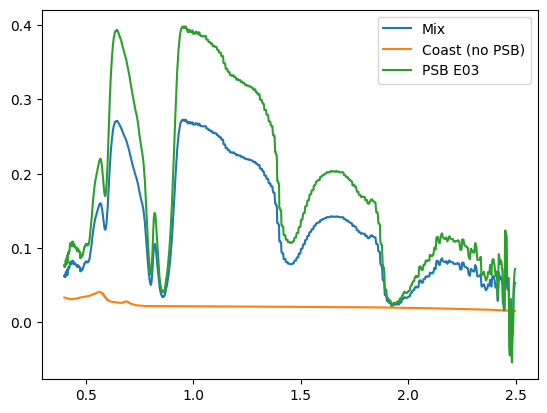

In [143]:
### Coastal PSB region

coast = spectres(wav_deep, regions['coast'][:,0], regions['coast'][:,1], fill = regions['coast'][:,1][0])
psb_spec = spectres(wav_deep, purple_spectra['PSB']['wet']['E07'][:,0]/1000., purple_spectra['PSB']['wet']['E03'][:,1], fill = purple_spectra['PSB']['wet']['E07'][:,1][0])

# plt.plot(purple_spectra['PSB']['wet']['E07'][:,0], purple_spectra['PSB']['wet']['E07'][:,1], label = 'PSB E07')
# plt.plot(regions['coast'][:,0], regions['coast'][:,1], label = 'Coastal')
plt.plot(wav_deep, coast*1/3 + psb_spec*2/3, label = 'Mix')
plt.plot(wav_deep, coast, label = 'Coast (no PSB)')
plt.plot(wav_deep, psb_spec, label = 'PSB E03')
plt.legend()
# plt.ylim(0.4, 0.5)

plt.show()

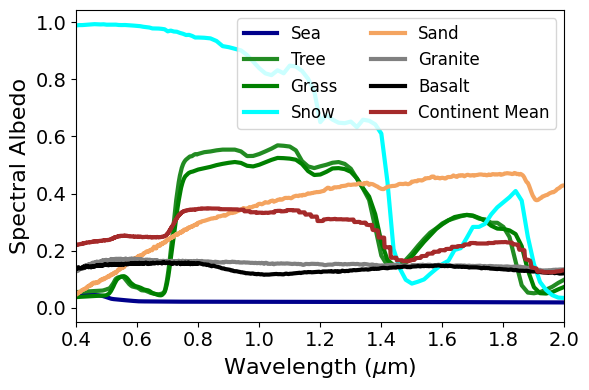

In [5]:
lw = 3
plt.figure(figsize=(6, 4))
plt.plot(regions['sea'][:, 0], regions['sea'][:, 1], label = 'Sea', color = 'darkblue', linewidth=lw)
plt.plot(regions['trees'][:, 0], regions['trees'][:, 1], label = 'Tree', color = 'forestgreen', linewidth=lw)
plt.plot(regions['grass'][:, 0], regions['grass'][:, 1], label = 'Grass', color = 'green', linewidth=lw)
plt.plot(regions['snow'][:, 0], regions['snow'][:, 1], label = 'Snow', color = 'aqua', linewidth=lw)
plt.plot(regions['sand'][:, 0], regions['sand'][:, 1], label = 'Sand', color = 'sandybrown', linewidth=lw)
plt.plot(regions['granite'][:, 0], regions['granite'][:, 1], label = 'Granite', color = 'grey', linewidth=lw)
plt.plot(regions['basalt'][:, 0], regions['basalt'][:, 1], label = 'Basalt', color = 'black', linewidth=lw)
plt.plot(regions['cont'][:, 0], regions['new_cont3'][:, 1], label = 'Continent Mean', color = 'brown', linewidth=lw)
plt.xlim(0.4, 2.5)
plt.xlabel('Wavelength (microns)')
plt.ylabel('Reflectance')
plt.legend(fontsize = 12, loc = 'upper right', ncol = 2)
# plt.title('Albedo of Surfaces on Earth', fontsize = 18)
plt.xlabel(r'Wavelength ($\mu$m)', fontsize=16)
plt.ylabel('Spectral Albedo', fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.xlim(0.4, 2.0)
plt.show()

In [5]:
# def add_clouds(map, spec = 4., min_size = 30, max_size = 140, num = 6):

#     ### This function takes a map and places random circular clouds over its surface. Call this function last, after coast. ###
#     map_dims = map.shape
#     cloud_pix = np.zeros((num, 3))

#     for i in range(num):
#         size = np.random.uniform(min_size, max_size)
        
#         lon = np.random.uniform(0, map_dims[1])
#         lat = np.random.uniform(0, map_dims[0])

#         r_pix = int(size / map_dims[0] * map_dims[1])

#         for x, y in np.ndindex(map.shape):
#             if (x - lat)**2 + (y - lon)**2 < r_pix**2:
#                 map[x, y] = spec

#         cloud_pix[i] = (lat, lon, r_pix)
    
#     cum_coverage = (1. - np.count_nonzero(map - spec) / (map_dims[0] * map_dims[1])) * 100.

#     print("{} percent cloud coverage".format(cum_coverage))
#     plt.imshow(map)
#     plt.colorbar()
#     plt.show()

#     return map, cum_coverage

# def add_coast(map, spec = 2., size = 3.):
#     coast_pix = 0

#     coast_ij = np.zeros((map.shape[0], map.shape[1]))

#     for row in range(len(map[:,0]) - 1):
#         for col in range(len(map[0]) - 1):
#             if map[row, col] != map[row, col+1]:
#                 coast_ij[row, col] = 1.
#             if map[row, col] != map[row + 1, col]:
#                 coast_ij[row, col] = 0.8


#     for row in range(len(coast_ij[:,0])):
#         for col in range(len(coast_ij[0])):

#             if coast_ij[row, col] == 1.:
#                 map[row, col] = spec
#                 for i in range(size):
#                     if col + i < len(coast_ij[0]):
#                         map[row, col+i] = spec
#                         coast_pix += 1
#                     if col - i > 0:
#                         map[row, col-i] = spec
#                         coast_pix += 1

#             if coast_ij[row, col] == 0.8:
#                 map[row, col] = spec
#                 for i in range(size):
#                     if row + i < len(coast_ij[:,0]):
#                         map[row+i, col] = spec
#                         coast_pix += 1
#                     if row - i > 0:
#                         map[row-i, col] = spec
#                         coast_pix += 1

#     percent_coast = (coast_pix / (map.shape[0] * map.shape[1])) * 100.
#     print("This map is {} percent coast".format(percent_coast))
    
#     plt.imshow(map)
#     plt.colorbar()
#     plt.show()

#     return map, percent_coast

# def add_poles(map, spec = 3., sea_north = 25, cont_north = 41, sea_south = 25, cont_south = 41):
    
#     ### This function takes a map and places polar caps at the poles. Call this function after coast, but before clouds. ###
#     ### North and south give pixel rows to assign as polar regions from top and bottom of map. ###  

#     map[:sea_north] = spec
#     map[-sea_south:] = spec
#     map[sea_north:cont_north][map[sea_north:cont_north] == 1.] = spec
#     map[-cont_south:-sea_south][map[-cont_south:-sea_south] == 1.] = spec

#     cum_coverage = (1. - np.count_nonzero(map - spec) / (map.shape[0] * map.shape[1])) * 100.

#     print("{} percent polar coverage".format(cum_coverage))
#     plt.imshow(map)
#     plt.colorbar()
#     plt.show()

#     return map, cum_coverage


# ### Version before class implementation

# def make_spectral_map(
#         map,
#         wav, 
#         cont_id, 
#         cont_spec, 
#         ocean_id, 
#         ocean_spec, 
#         cloud_id = None,
#         cloud_spec = None,
#         snow_id = None,
#         snow_spec = None,
#         coast_id = None,
#         coast_spec = None,
#         ydeg = 20,
#         scalar_wav = 0.7,
#         smoothing = 0.1
#     ):
    
#     ### This function takes a map and assigns spectral values to different regions.                     ###
#     ### The ID values are the code for that region in the map.                                          ###
#     ### The spec values are the spectral reflectance of that region, and should be same length as wav.  ###
#     ### Function assumes map has at least continents and oceans.                                        ###

#     map_refl_spec = np.ones((len(wav), 320, 640))
#     specmap_y = np.zeros((len(wav), (ydeg+1)**2))
#     specmap_y_shift = np.zeros((len(wav), (ydeg+1)**2))
#     specmap_p = np.zeros((len(wav), 996))
#     minpix = np.zeros((len(wav)))
#     maxpix = np.zeros((len(wav)))
#     amps = np.zeros((len(wav)))

#     specmap = starry.Map(ydeg = ydeg, reflected=True)
#     scalarmap = starry.Map(ydeg = ydeg, reflected=True)

#     if cloud_id is None:
#         cloud_spec = np.nan * np.ones(len(wav))
#     if snow_id is None:
#         snow_spec = np.nan * np.ones(len(wav))
#     if coast_id is None:
#         coast_spec = np.nan * np.ones(len(wav))

#     for wl in range(len(wav)):
    
#         specmap.reset()
#         image = map.copy()

#         image[image == cont_id] = cont_spec[wl]
#         image[image == ocean_id] = ocean_spec[wl]
#         if cloud_id is not None:
#             image[image == cloud_id] = cloud_spec[wl]
#         if snow_id is not None:
#             image[image == snow_id] = snow_spec[wl]
#         if coast_id is not None:
#             image[image == coast_id] = coast_spec[wl]

#         map_refl_spec[wl] = image

#         specmap.load(image, smoothing = smoothing)
#         specmap_y[wl] = specmap.y

#         _, _, Y2P, P2Y, _, _ = specmap.get_pixel_transforms()
#         p = Y2P.dot(specmap.y)

#         #Pixel stretch to match max/min albedo to max/min pixel value
#         maxi = np.nanmax((cont_spec[wl], ocean_spec[wl], cloud_spec[wl], snow_spec[wl], coast_spec[wl]))
#         mini = np.nanmin((cont_spec[wl], ocean_spec[wl], cloud_spec[wl], snow_spec[wl], coast_spec[wl]))

#         p = p / np.max(p) * (maxi - mini) + np.min(p)

#         #Pixel shift to set min val 
        
#         #shift = np.min(p) - 0.1         # shift the pixel values so that the minimum is 0.1
#         shift = np.min(p) - mini      # shift the pixel values so that the minimum is ocean reflectance
#         p = p - shift

#         specmap_p[wl] = p

#         y = P2Y.dot(p)

#         specmap_y_shift[wl] = y

#         minpix[wl] = np.min(p)
#         maxpix[wl] = np.max(p)  
        
#         amps[wl] = y[0] * 0.4
#         amps[wl] = y[0]

#         if wav[wl] <= scalar_wav and wav[wl + 1] > scalar_wav:
#             print(np.max(image))
#             plt.imshow(image)
#             plt.colorbar().set_label(label='Gemoetric Albedo',size=16)
#             plt.title('Albedo distribution at {} um'.format(scalar_wav), fontsize = 18)
#             plt.show()
#             scalarmap.load(np.flipud(image), smoothing = 0.1)
        
#     fullspecmap = starry.Map(ydeg=ydeg, reflected=True, nw = len(wav), wav = wav)

#     for wl in range(len(wav)):
#         fullspecmap[1:, :, wl] = specmap_y_shift[wl][1:]/specmap_y_shift[wl][0]
#         fullspecmap.amp[wl] = specmap_y_shift[wl][0]
    
#     ### Function returns:
#     ### fullspecmap: a multiwavelength starry map with the spectral reflectance encoded  - feed this into the simulated observation
#     ### scalarmap: a starry map with the reflectance values of the map at the scalar wavelength - for visualisation purposes
#     ### map_refl_spec: the image of the map for each wavelength
#     ### specmap_y: the spherical harmonic coefficients for each wavelength before pixel stretching
#     ### specmap_y_shift: the spherical harmonic coefficients for each wavelength after pixel stretching
#     ### specmap_p: the pixel values for each wavelength
#     ### minpix: the minimum pixel value for each wavelength
#     ### maxpix: the maximum pixel value for each wavelength
#     ### amps: the amplitude of the y0 coefficient for each wavelength
  
#     return fullspecmap, scalarmap, map_refl_spec, specmap_y, specmap_y_shift, specmap_p, minpix, maxpix, amps


# def refl_spec_obs(
#         map,
#         scalarmap,
#         stellar_spec,           #Spectrum incident on the planet 
#         num_obs = 30, 
#         num_nights = 1,
#         texp = 30.,             #Observational units assumed to be in minutes (texp, cadence)
#         cadence = 60.,          
#         phase_init = 90.,       #Initial phase of the planet in degrees, where 0 is transit, 180 is secondary eclipse
#         theta_init = 0., 
#         snr = 30.,
#         D_telescope = 39.,      #Telescope aperture in m
#         comp_time = 1.,         #Cadence of starry flux computations to be integrated, in minutes 
#         a = 150E6,              #Orbit/planet scales in units of km (a, R)
#         Rp = 6400.,
#         Mp = 0.,
#         Rstar = 700000.,
#         Mstar = None,
#         prot = 1., 
#         porb = 365.25,          #Orbital and rotational periods in units of days (prot, porb)
#         obl = 0.,
#         p_inc = 90.,
#         orb_inc = 90.,
#         ecc = 0.,
#         omega = 0.,             #Orbital longitude of ascending node in degrees - 0 is primary transit
#         dist = 5.,              #Distance to system in parsecs
#         plot = True
#     ):

#     if cadence < texp:
#         print('Warning! Cadence is less than exposure time. Correct if you want meaningful results.')
    
#     ###########################################################
#     # Compute the observation times and number of evaluations #
#     ###########################################################    
#     obs_per_night = np.zeros(num_nights)
#     for night in range(num_nights):
#         obs_per_night[night] = round(num_obs / num_nights)
#         #print(obs_per_night[night])
#         if obs_per_night[night] * cadence > (12 * 60.):
#             print('Warning! Observation time per night is greater than 12 hours. Conisder breaking into multiple nights for ground based observations.')
         
#     # obs_per_night[-1] = num_obs - np.sum(obs_per_night[:-1])
#     # if obs_per_night[-1] * cadence > (12 * 60.):
#     #     print('Warning! Observation time per night is greater than 12 hours. Conisder breaking into multiple nights for ground based observations.')

#     obs_time = (num_nights - 1) * 24. * 60. + obs_per_night[-1] * cadence

#     num_eval = int(obs_time/comp_time)

#     t_obs = np.zeros((num_nights, int(obs_per_night[0])))
#     for night in range(num_nights):
#         t_obs[night] = np.arange(night * 24. * 60., night * 24. * 60. + obs_per_night[night] * cadence, cadence)
    
#     #########################################################
#     # Compute planet's orbital position at each observation #
#     #########################################################
    
#     phase_final = phase_init + obs_time / (porb * 24 * 60.) * 360.
#     obs_phase = np.linspace(phase_init, phase_final, num_eval)

#     # r = a/Rp # Planet - star distance in units of planet radii
#     # #Phase = 0 is secondary eclipse, phase = 180 is transit
#     # x = r * np.sin(np.deg2rad(obs_phase))
#     # z = r * np.cos(np.deg2rad(obs_phase))
#     # y = np.zeros_like(x)

#     # ang_sep = x * Rp/(dist * 30856775814671.914)

#     #######################################################################
#     # Alternate method for computing orbital position using starry system #
#     #######################################################################
    
#     Mstar_kep = (a * 1000.) ** 3 / ((porb * 24. * 60. * 60.) ** 2) * 4 * np.pi ** 2 / 6.6743E-11 - Mp
#     if Mstar is None:
#         Mstar = Mstar_kep
#     elif not np.isclose(Mstar, Mstar_kep):
#         print('Stellar mass is inconsistent with Kepler\'s third law. Using {} kg instead of {} kg.'.format(Mstar_kep, Mstar))
#         Mstar = Mstar_kep

#     star = starry.Primary(starry.Map(ydeg = 0), r = Rstar, m = Mstar, length_unit = u.km, time_unit = u.day, mass_unit = u.kg)
#     planet = starry.Secondary(starry.Map(ydeg = 0, obl = obl, inc = p_inc), 
#                               r = Rp, m = Mp, a = a, prot = prot, omega = omega, inc = orb_inc, t0 = 0. - (phase_init/360.) * porb, ecc = ecc,
#                               time_unit = u.day, length_unit = u.km, mass_unit = u.Mearth)
#     system = starry.System(star, planet)

#     eval_time = np.linspace(0, obs_time, num_eval)/60./24.
#     xp, yp, zp = system.position(eval_time)

#     x = (xp[0] - xp[1]) / Rp
#     y = (yp[1] - yp[0]) / Rp
#     z = (zp[0] - zp[1]) / Rp

#     ang_sep = np.sqrt(x ** 2 + y ** 2) * Rp/(dist * 30856775814671.914)

#     ################################################################
#     # Compute the rotation angle of the planet at each observation #
#     ################################################################

#     theta_final = theta_init + obs_time / (prot * 24 * 60.) * 360.
#     theta = np.linspace(theta_init, theta_final, num_eval)

#     #Compute the flux throughout the observation
#     map.obl = obl
#     map.inc = p_inc
#     scalarmap.obl = obl
#     scalarmap.inc = p_inc
#     flux = map.flux(theta = theta, xs = x, ys = y, zs = z, rs = Rstar/Rp) * stellar_spec

#     ### Create a "perfect" map for comparison
#     planet_perfect = starry.Map(ydeg = map.ydeg, nw = map.nw, reflected = True)
#     planet_perfect.amp = 1.
#     planet_perfect.obl = obl
#     planet_perfect.inc = p_inc
#     flux_perfect = planet_perfect.flux(theta = theta, xs = x, ys = y, zs = z, rs = Rstar/Rp) * stellar_spec


#     #############################################################
#     # Integrate over the exposure time to get the observed flux #
#     #############################################################
#     int_flux = np.zeros((num_nights, int(obs_per_night[0]), len(map.wav)))
#     int_stellar = np.zeros((num_nights, int(obs_per_night[0]), len(map.wav)))
#     int_flux_perfect = np.zeros((num_nights, int(obs_per_night[0]), len(map.wav)))
    
#     if num_nights == 1:
#         obs_params = {
#             'x': np.zeros(2), 
#             'z': np.zeros(2), 
#             'theta': np.zeros(2),
#             'ang_sep': np.zeros(2),
#             'obs_phase': np.zeros(2)
#             }
#         start = int(t_obs[0] / comp_time)
#         end = start + int(texp / comp_time) - 1
#         int_flux[0] = integrate.simpson(flux[start:end], dx = comp_time * 60., axis = 0) 
#         int_stellar = stellar_spec * (end - start) * comp_time * 60. 
#         int_flux_perfect[0] = integrate.simpson(flux_perfect[start:end], dx = comp_time * 60., axis = 0) 

#         obs_params['x'][0] = x[start]
#         obs_params['z'][0] = z[start]
#         obs_params['theta'][0] = theta[start]
#         obs_params['ang_sep'][0] = ang_sep[start]
#         obs_params['obs_phase'][0] = obs_phase[start]

#         obs_params['x'][1] = x[end]
#         obs_params['z'][1] = z[end]
#         obs_params['theta'][1] = theta[end]
#         obs_params['ang_sep'][1] = ang_sep[end]
#         obs_params['obs_phase'][1] = obs_phase[end]
#     else:
#         for night in range(num_nights):
#             obs_params = {
#                 'x': np.zeros((num_nights, int(obs_per_night[0]))), 
#                 'z': np.zeros((num_nights, int(obs_per_night[0]))), 
#                 'theta': np.zeros((num_nights, int(obs_per_night[0]))),
#                 'ang_sep': np.zeros((num_nights, int(obs_per_night[0]))),
#                 'obs_phase': np.zeros((num_nights, int(obs_per_night[0])))
#                 }
#             for i in range(len(t_obs[night])):
#                 start = int(t_obs[night][i] / comp_time)
#                 #print(start)
#                 end = start + int(texp / comp_time)
#                 #print(end)
#                 int_flux[night][i] = integrate.simpson(flux[start:end], dx = comp_time, axis = 0)

#                 obs_params['x'][night][i] = x[start]
#                 obs_params['z'][night][i] = z[start]
#                 obs_params['theta'][night][i] = theta[start]
#                 obs_params['ang_sep'][night][i] = ang_sep[start]
#                 obs_params['obs_phase'][night][i] = obs_phase[start]


#     #########################
#     # Add noise to the flux #
#     #########################
#     wav = map.wav
#     res = .700 / ((wav[wav >= 0.7][0] - wav[wav < 0.7][-1])) # Resolution
#     # num_res_elements = 100/res

#     if len(snr) == 1:
#         scale = np.ones_like(wav) * np.max(int_flux)/snr 
#     elif len(snr) == len(wav):
#         scale = int_flux/snr 
#     else:
#         print('Warning! SNR must be a single value or an array of the same length as the number of wavelengths.')
#         print('Setting SNR to 10.')
#         scale = np.ones_like(wav) * np.max(int_flux)/10.  
    
#     # noise = np.random.normal(0, scale, size = (num_nights, int(obs_per_night[0]), len(wav)))
#     # int_flux_noise = int_flux + noise

#     noise = np.ones_like(wav)
#     for i in range(len(wav)):
#         noise[i] = np.random.normal(0, scale[0][0][i])
#     int_flux_noise = int_flux + noise

#     print("This observation lasts for {} days at R = {} (at 700 nm)."
#         .format(
#             np.round(obs_time/(60*24), decimals=2), 
#             np.round(res, decimals = 2)
#             ))
    
#     print("The planet moves from phase angle between {} and {} degrees and at a rotation angle between {} and {} degrees."
#           .format(
#             obs_phase[0], 
#             np.round(obs_phase[-1], decimals=1), 
#             theta[0], 
#             np.round(theta[-1]%360., decimals=1)
#     ))

#     print("The planet completes {} rotations and {} orbits."
#           .format(
#             np.round((theta[-1] - theta[0])/360., decimals=2),
#             np.round((obs_phase[-1] - obs_phase[0])/360., decimals=2)
#           ))
    
#     ##########################
#     # Plot the observed flux #
#     ##########################
#     # mpl.rcParams.update(mpl.rcParamsDefault)
#     # plt.rcParams['text.usetex'] = False
#     elt_angles = (2*700E-9/38.5, 3*700E-9/38.5)
#     elt_labels = ('2lambda/D', '3lambda/D')

#     int_albedo = int_flux[0][0]/int_flux_perfect[0][0]
#     int_albedo_noise = int_flux_noise[0][0]/int_flux_perfect[0][0]

#     if plot == True:
#         # Create a figure and axes
#         if num_nights == 1:
#             fig, axs = plt.subplots(4, 3, figsize=(20, 30))

#             ax = axs[0][0]
#             ax.plot(map.wav, int_flux[0][0])
#             ax.set_xlabel('Wavelength (micron)')
#             ax.set_ylabel('Flux (pixels per resolution element)')
#             ax.set_ylim(np.min(int_flux[0][0] * 0.9), np.max(int_flux[0][0]) * 1.1)
#             ax.set_title('Simulated Observation (No Noise)')

#             ax = axs[0][1]
#             ax.errorbar(map.wav, int_flux_noise[0][0], yerr = scale[0][0], fmt = 'o')
#             ax.plot(map.wav, int_flux[0][0], color = 'black', alpha = 0.5)
#             ax.set_xlabel('Wavelength (micron)')
#             ax.set_ylabel('Flux (pixels per resolution element)')
#             ax.set_ylim(np.min(int_flux[0][0] * 0.9), np.max(int_flux[0][0]) * 1.1)
#             ax.set_title('Simulated Observation (With Noise)')

#             ax = axs[1][0]
#             ax.plot(map.wav, int_flux[0][0]/int_flux_perfect[0][0])
#             ax.set_xlabel('Wavelength (micron)')
#             ax.set_ylabel('Reflectance')
#             ax.set_ylim(np.min(int_flux[0][0]/int_flux_perfect[0][0]) * 0.9, np.max(int_flux[0][0]/int_flux_perfect[0][0]) * 1.1)
#             ax.set_title('Simulated Reflection Spectrum (No Noise)')

#             ax = axs[1][1]
#             ax.errorbar(map.wav, int_flux_noise[0][0]/int_flux_perfect[0][0], yerr = scale[0][0]/int_flux_perfect[0][0], fmt = 'o')
#             ax.plot(map.wav, int_flux[0][0]/int_flux_perfect[0][0], color = 'black', alpha = 0.5)
#             ax.set_xlabel('Wavelength (micron)')
#             ax.set_ylabel('Reflectance')
#             ax.set_ylim(np.min(int_flux[0][0]/int_flux_perfect[0][0]) * 0.9, np.max(int_flux[0][0]/int_flux_perfect[0][0]) * 1.1)
#             ax.set_title('Simulated Reflection Spectrum (With Noise)')

#             ax = axs[2][0]
#             scalarmap.show(
#                 theta = obs_params['theta'][0], 
#                 xs = obs_params['x'][0], 
#                 ys = np.zeros_like(obs_params['x'][0]), 
#                 zs = obs_params['z'][0], 
#                 ax = ax)
            
#             ax = axs[2][1]
#             scalarmap.show(
#                 theta = obs_params['theta'][-1], 
#                 xs = obs_params['x'][-1], 
#                 ys = np.zeros_like(obs_params['x'][-1]), 
#                 zs = obs_params['z'][-1], 
#                 ax = ax)
            
#             ax = axs[3][0]
#             ax.plot(np.linspace(0, texp, 20), np.linspace(obs_params['ang_sep'][0], obs_params['ang_sep'][-1], 20))
#             ax.hlines(elt_angles[0], 0, texp, color = 'red', linestyle = '--', label = elt_labels[0])
#             ax.hlines(elt_angles[1], 0, texp, color = 'blue', linestyle = '--', label = elt_labels[1])
#             ax.set_xlabel('Obs Time (Night {})'.format(night + 1))
#             ax.set_ylabel('Angular Separation')
#             ax.set_title('Angular Separation')
#             ax.legend()

#             ax = axs[3][1]
#             ax.plot(np.linspace(0, texp, 20), np.linspace(obs_params['obs_phase'][0], obs_params['obs_phase'][-1], 20), label = 'Phase Angle')
#             ax.plot(np.linspace(0, texp, 20), np.linspace(obs_params['theta'][0], obs_params['theta'][-1], 20), label = 'Rotation Angle')
#             ax.set_xlabel('Obs Time (Night {})'.format(night + 1))
#             ax.set_ylabel('Angle')
#             ax.set_title('Phase and Rotation Angles')
#             ax.legend()

#             # axs[0].set_title('Simulated Reflection Spectrum (No Noise)')
#             # axs[1].set_title('Simulated Reflection Spectrum (With Noise)')
#             # axs[2].set_title('Illumination of Planet - Start of night')
#             # axs[3].set_title('Illumination of Planet - End of night')
#             # axs[4].set_title('Angular Separation')

#             plt.show()

#         else:
#             fig, axs = plt.subplots(num_nights, 5, figsize=(37.5,5 * num_nights))
#             cmap = plt.get_cmap('viridis')

#             for night in range(num_nights):
#                 # Get the current axis
#                 ax = axs[night][0]
#                 # Create a color mapping
#                 norm = plt.Normalize(vmin=np.min(int_flux[night]*1E9), vmax=np.max(int_flux[night]*1E9))
#                 # Plot the flux as an image with color mapping
#                 im = ax.imshow(int_flux[night]*1E9, cmap=cmap, norm=norm, aspect='auto', origin = 'lower',
#                                 extent=(wav[0], wav[-1], t_obs[night][0] - night * 24 * 60., t_obs[night][-1] - night * 24 * 60.))
#                 # Add a color bar to show the mapping
#                 cbar = ax.figure.colorbar(im, ax=ax)
#                 # Add labels and titles
#                 ax.set_ylabel('Obs Time (Night {})'.format(night + 1))
#                 cbar.ax.set_ylabel('Flux (ppb)')
#                 ax.set_xlabel('Wavelength (micron)')

#                 ax = axs[night][1]
#                 norm = plt.Normalize(vmin=np.min(int_flux_noise[night]*1E9), vmax=np.max(int_flux_noise[night]*1E9))
#                 im = ax.imshow(int_flux_noise[night]*1E9, cmap=cmap, norm=norm, aspect='auto', origin = 'lower',
#                                 extent=(wav[0], wav[-1], t_obs[night][0] - night * 24 * 60., t_obs[night][-1] - night * 24 * 60.))
#                 cbar = ax.figure.colorbar(im, ax=ax)
                
#                 ax.set_xlabel('Wavelength (micron)')
#                 ax.set_ylabel('Obs Time (Night {})'.format(night + 1))
#                 cbar.ax.set_ylabel('Flux (ppb)')

#                 ax = axs[night][2]
#                 scalarmap.show(
#                     theta = obs_params['theta'][night][0], 
#                     xs = obs_params['x'][night][0], 
#                     ys = np.zeros_like(obs_params['x'][night][0]), 
#                     zs = obs_params['z'][night][0], 
#                     ax = ax)
                
#                 ax = axs[night][3]
#                 scalarmap.show(
#                     theta = obs_params['theta'][night][-1], 
#                     xs = obs_params['x'][night][-1], 
#                     ys = np.zeros_like(obs_params['x'][night][-1]), 
#                     zs = obs_params['z'][night][-1], 
#                     ax = ax, illuminate = False)
                
#                 ax = axs[night][4]
#                 ax.plot(t_obs[night], obs_params['ang_sep'][night])
#                 ax.hlines(elt_angles[0], t_obs[night][0], t_obs[night][-1], color = 'red', linestyle = '--', label = elt_labels[0])
#                 ax.hlines(elt_angles[1], t_obs[night][0], t_obs[night][-1], color = 'blue', linestyle = '--', label = elt_labels[1])
#                 ax.set_xlabel('Obs Time (Night {})'.format(night + 1))
#                 ax.set_ylabel('Angular Separation')
#                 ax.legend()
#                 ax_b = ax.twinx()
#                 ax_b.plot(t_obs[night], obs_params['obs_phase'][night], color = 'green')
#                 ax_b.set_ylabel('Phase Angle')

#             axs[0][0].set_title('Simulated Reflection Spectrum (No Noise)')
#             axs[0][1].set_title('Simulated Reflection Spectrum (With Noise)')
#             axs[0][2].set_title('Illumination of Planet - Start of night')
#             axs[0][3].set_title('Illumination of Planet - End of night')
#             axs[0][4].set_title('Angular Separation')

#             plt.show()

#     ### Function returns:
#     ### int_flux: the observed flux without noise
#     ### int_flux_noise: the observed flux with noise
#     ### flux: the flux throughout the observation prior to integration - the pure signal generated from the model
#     ### obs_phase: the phase of the planet at each observation
#     ### theta: the rotation angle of the planet at each observation
#     ### obs_time: the total observation time
#     ### t_obs: the time of each observation

#     return int_flux, int_flux_noise, scale[0][0], int_albedo, int_albedo_noise, scale[0][0]/int_flux_perfect[0][0], flux, obs_phase, theta, obs_time, t_obs

# image0 = plt.imread('/Users/andrew/opt/anaconda3/envs/starry_stable/earth.png')

# # Assigning continent values to 1, ocean values to 0 
# image0[image0 < 0.5] = 0.
# image0[image0 >= 0.5] = 1.

# plt.imshow(image0)
# plt.colorbar()
# plt.show()


# image0, _ = add_coast(image0, 2., size = 5)

# image0, _ = add_poles(image0, 3., sea_north = 25, cont_north = 41, sea_south = 25, cont_south = 41)

# # image0, _ = add_clouds(image0, 4., num = 5, max_size=70)

### Class to create a spectral map using assigned spectra

In [6]:
class SpectralMap:
    def __init__(
            self, 
            map_image, 
            wav, 
            cont_id, cont_spec, 
            ocean_id, ocean_spec, 
            cloud_id = None, cloud_spec = None, cloud_dims = (30, 140), cloud_num = 6,              #Cloud dims are min and max cloud sizes in degrees
            snow_id = None, snow_spec = None, snow_dims = (25, 41, 25, 41),                         #Snow dims are the pixel rows to assign as polar regions from top and bottom of map
            coast_id = None, coast_spec = None, coast_size = 3,
            ydeg = 20, 
            scalar_wav = 0.7, 
            smoothing = None, 
            roughness = 0.
        ):

        '''
        This class takes a map and assigns spectral values to different regions.
        The ID values are the code for that region in the map.                                         
        The spec values are the spectral reflectance of that region, and should be same length as wav.
        Function assumes map has at least continents and oceans. 
        '''
        map_image[map_image < 0.5] = ocean_id
        map_image[map_image >= 0.5] = cont_id

        self.map = np.flipud(map_image)
        self.wav = wav
        self.cont_id = cont_id
        self.cont_spec = cont_spec
        self.ocean_id = ocean_id
        self.ocean_spec = ocean_spec

        self.coast_id = coast_id
        if coast_id is None:
            self.coast_spec = np.nan * np.ones(len(wav))
        else:
            self.coast_spec = coast_spec
            self.map = self.add_coast(self.map, spec = coast_id, size = coast_size)

        self.snow_id = snow_id
        if snow_id is None:
            self.snow_spec = np.nan * np.ones(len(wav))
        else:
            self.snow_spec = snow_spec
            self.map = self.add_poles(self.map, spec = snow_id, sea_north = snow_dims[0], cont_north = snow_dims[1], sea_south = snow_dims[2], cont_south = snow_dims[3])

        self.cloud_id = cloud_id
        if cloud_id is None:
            self.cloud_spec = np.nan * np.ones(len(wav))
        else:
            self.cloud_spec = cloud_spec
            self.map = self.add_clouds(self.map, spec = cloud_id, min_size = cloud_dims[0], max_size = cloud_dims[1], num = cloud_num)

        self.ydeg = ydeg
        self.scalar_wav = scalar_wav
        self.smoothing = smoothing
        self.roughness = roughness
        self.fullspecmap = starry.Map(ydeg=self.ydeg, reflected=True, nw = len(self.wav), wav = self.wav, roughness=self.roughness)
        self.scalarmap = starry.Map(ydeg = self.ydeg, reflected=True, roughness=self.roughness)
        _, _, Y2P, _, _, _ = self.scalarmap.get_pixel_transforms()
        p = Y2P.dot(self.scalarmap.y)
        self.specmap_p = np.zeros((len(self.wav), p.shape[0]))

        print("Spectral map created. Call get_specmap() to get the full spectral map.")
        self.surface_dist = self.get_pixel_ratio(to_print = False)
        self.surface_area = self.get_areas()

    def get_pixel_ratio(self, to_plot = True, to_print = True):
        ids, num = np.unique(self.map, return_counts = True)
        tot = self.map.shape[0] * self.map.shape[1]
        
        if to_print:

            print("The continent is {} percent of the map pixels".format(np.round(num[ids == self.cont_id] / tot * 100.), decimals = 1))
            print("The ocean is {} percent of the map pixels".format(np.round(num[ids == self.ocean_id] / tot * 100.), decimals = 1))
            if self.cloud_id is not None:
                print("The clouds are {} percent of the map pixels".format(np.round(num[ids == self.cloud_id] / tot * 100.), decimals = 1))
            if self.snow_id is not None:
                print("The poles are {} percent of the map pixels".format(np.round(num[ids == self.snow_id] / tot * 100.), decimals = 1))
            if self.coast_id is not None:
                print("The coast is {} percent of the map pixels".format(np.round(num[ids == self.coast_id] / tot * 100.), decimals = 1))
  
        if to_plot:
            fig = plt.figure()
            ax = plt.axes()
            im = ax.imshow(np.flipud(self.map))
            plt.title('Map with regions assigned', fontsize = 18)
            cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
            plt.colorbar(im, cax=cax)
            plt.show()
        
        return dict(zip(ids, num))
    
    def get_areas(self, to_print = True):
        ids_glob = np.unique(self.map)
        delta_lat = (np.pi / (self.map.shape[0] - 1))
        A_tot = 0.
        A_surface_type = dict.fromkeys(ids_glob, 0.)
        
        for row in range(self.map.shape[0]):
            ids, num = np.unique(self.map[row,:], return_counts = True)
            # row_lat = (row + 0.5) * delta_lat - np.pi/2.
            row_lat = row * delta_lat - np.pi/2.

            # A_lat = 2 * np.pi * np.cos(row_lat) * delta_lat
            A_lat = 2 * np.pi * (np.sin(row_lat + delta_lat) - np.sin(row_lat))
            A_tot += A_lat

            for i, id in enumerate(ids):
                A_surface_type[id] += num[i]/self.map.shape[1] * A_lat
        
        for key in A_surface_type.keys():
            A_surface_type[key] = A_surface_type[key] / A_tot

        if to_print:
            print("The map has a total area of {}pi square radians".format(np.round(A_tot/np.pi, decimals = 1)))
            print("The continent is {} percent of the map area".format(np.round(A_surface_type[self.cont_id] * 100.), decimals = 1))
            print("The ocean is {} percent of the map area".format(np.round(A_surface_type[self.ocean_id] * 100.), decimals = 1))
            if self.cloud_id is not None:
                print("The clouds are {} percent of the map area".format(np.round(A_surface_type[self.cloud_id] * 100.), decimals = 1))
            if self.snow_id is not None:
                print("The poles are {} percent of the map area".format(np.round(A_surface_type[self.snow_id] * 100.), decimals = 1))
            if self.coast_id is not None:
                print("The coast is {} percent of the map area".format(np.round(A_surface_type[self.coast_id] * 100.), decimals = 1))
  
        return A_surface_type

    def add_clouds(self, map, spec = 4., min_size = 30, max_size = 140, num = 6):

        ### This function takes a map and places random circular clouds over its surface. Call this function last, after coast. ###
        map_dims = map.shape
        cloud_pix = np.zeros((num, 3))

        for i in range(num):
            size = np.random.uniform(min_size, max_size)
            
            lon = np.random.uniform(0, map_dims[1])
            lat = np.random.uniform(0, map_dims[0])

            r_pix = int(size / map_dims[0] * map_dims[1])

            for x, y in np.ndindex(map.shape):
                if (x - lat)**2 + (y - lon)**2 < r_pix**2:
                    map[x, y] = spec

            cloud_pix[i] = (lat, lon, r_pix)

        return map

    def add_coast(self, map, spec = 2., size = 3.):

        coast_ij = np.zeros((map.shape[0], map.shape[1]))

        for row in range(len(map[:,0]) - 1):
            for col in range(len(map[0]) - 1):
                if map[row, col] != map[row, col+1]:
                    coast_ij[row, col] = 1.
                if map[row, col] != map[row + 1, col]:
                    coast_ij[row, col] = 0.8


        for row in range(len(coast_ij[:,0])):
            for col in range(len(coast_ij[0])):

                if coast_ij[row, col] == 1.:
                    map[row, col] = spec
                    for i in range(size):
                        if col + i < len(coast_ij[0]):
                            map[row, col+i] = spec

                        if col - i > 0:
                            map[row, col-i] = spec
                           

                if coast_ij[row, col] == 0.8:
                    map[row, col] = spec
                    for i in range(size):
                        if row + i < len(coast_ij[:,0]):
                            map[row+i, col] = spec
                         
                        if row - i > 0:
                            map[row-i, col] = spec
                     
        return map

    def add_poles(self, map, spec = 3., sea_north = 25, cont_north = 41, sea_south = 25, cont_south = 41):
        
        ### This function takes a map and places polar caps at the poles. Call this function after coast, but before clouds. ###
        ### North and south give pixel rows to assign as polar regions from top and bottom of map. ###  

        map[:sea_north] = spec
        map[-sea_south:] = spec
        map[sea_north:cont_north][map[sea_north:cont_north] == 1.] = spec
        map[-cont_south:-sea_south][map[-cont_south:-sea_south] == 1.] = spec

        return map

    def get_specmap(self, new_ydeg = None, new_wav = None, new_smoothing = None, new_scalar_wav = None, plot_scalar = True, return_map_only = True):
        if new_ydeg is not None:
            self.ydeg = new_ydeg
        if new_wav is not None:
            self.wav = new_wav
        if new_smoothing is not None:
            self.smoothing = new_smoothing
        if new_scalar_wav is not None:
            self.scalar_wav = new_scalar_wav

        map_refl_spec = np.ones((len(self.wav), self.map.shape[0], self.map.shape[1]))
        specmap_y = np.zeros((len(self.wav), (self.ydeg +1 ) ** 2))
        specmap_y_shift = np.zeros((len(self.wav), (self.ydeg + 1) ** 2))
        minpix = np.zeros((len(self.wav)))
        maxpix = np.zeros((len(self.wav)))
        amps = np.zeros((len(self.wav)))
        
        for wl in range(len(self.wav)):
            map_refl_spec[wl], specmap_y[wl], specmap_y_shift[wl], self.specmap_p[wl], minpix[wl], maxpix[wl], amps[wl] = self._comp_scalarmap(wl)

            if plot_scalar and self.wav[wl] <= self.scalar_wav and self.wav[wl + 1] > self.scalar_wav:
                fig = plt.figure()
                ax = plt.axes()
                im = ax.imshow(np.flipud(map_refl_spec[wl]))
                plt.title('Albedo distribution at {} um'.format(np.round(self.scalar_wav, decimals = 2)), fontsize = 18)
                cax = fig.add_axes([ax.get_position().x1+0.01,ax.get_position().y0,0.02,ax.get_position().height])
                plt.colorbar(im, cax=cax).set_label(label='Albedo',size=16)
                plt.show()

                self.scalarmap.amp = amps[wl]
                self.scalarmap[1:, :] = specmap_y_shift[wl][1:]/amps[wl]
                # self.scalarmap[1:, :] = specmap_y[wl][1:]/amps[wl]
            
            self.fullspecmap[1:, :, wl] = specmap_y_shift[wl][1:]/amps[wl]
            # self.fullspecmap[1:, :, wl] = specmap_y[wl][1:]/amps[wl]
            self.fullspecmap.amp[wl] = amps[wl] * 0.4
        
        ### Function returns:
        ### fullspecmap: a multiwavelength starry map with the spectral reflectance encoded  - feed this into the simulated observation
        ### scalarmap: a starry map with the reflectance values of the map at the scalar wavelength - for visualisation purposes
        ### map_refl_spec: the image of the map for each wavelength
        ### specmap_y: the spherical harmonic coefficients for each wavelength before pixel stretching
        ### specmap_y_shift: the spherical harmonic coefficients for each wavelength after pixel stretching
        ### specmap_p: the pixel values for each wavelength
        ### minpix: the minimum pixel value for each wavelength
        ### maxpix: the maximum pixel value for each wavelength
        ### amps: the amplitude of the y0 coefficient for each wavelength
        
        if return_map_only:
            return self.fullspecmap
        else:
            return self.fullspecmap, self.scalarmap, map_refl_spec, specmap_y, specmap_y_shift, self.specmap_p, minpix, maxpix, amps

    def get_scalarmap(self, wl, new_ydeg = None, plot_map = True):
        if new_ydeg is not None:
            self.ydeg = new_ydeg

        i = (np.abs(self.wav) - wl).argmin()

        map, _, y, _, _, _, amp = self._comp_scalarmap(i)

        if plot_map:
            plt.imshow(np.flipud(map))
            plt.colorbar().set_label(label='Albedo',size=16)
            plt.title('Albedo distribution at {} um'.format(np.round(self.scalar_wav, decimals = 3)), fontsize = 18)
            plt.show()

        self.scalarmap.amp = amp
        self.scalarmap[1:, :] = y[1:]/amp
      
        return self.scalarmap

    def _comp_scalarmap(self, wav_index):
        i = wav_index

        self.scalarmap.reset()
        image = self.map.copy()
        image[image == self.cont_id] = self.cont_spec[i]
        image[image == self.ocean_id] = self.ocean_spec[i]
        if self.cloud_id is not None:
            image[image == self.cloud_id] = self.cloud_spec[i]
        if self.snow_id is not None:
            image[image == self.snow_id] = self.snow_spec[i]
        if self.coast_id is not None:
            image[image == self.coast_id] = self.coast_spec[i]

        self.scalarmap.load(image, smoothing = self.smoothing, force_psd = True)
        specmap_y = self.scalarmap.y

        _, _, Y2P, P2Y, _, _ = self.scalarmap.get_pixel_transforms()
        p = Y2P.dot(self.scalarmap.y)

        #Pixel stretch to match max/min albedo to max/min pixel value
        maxi = np.nanmax((self.cont_spec[i], self.ocean_spec[i], self.cloud_spec[i], self.snow_spec[i], self.coast_spec[i]))
        mini = np.nanmin((self.cont_spec[i], self.ocean_spec[i], self.cloud_spec[i], self.snow_spec[i], self.coast_spec[i]))

        p = p / np.max(p) * (maxi - mini) + np.min(p)

        #Pixel shift to set min val 
        shift = np.min(p) - mini      # shift the pixel values so that the minimum is ocean reflectance
        p = p - shift

        specmap_p = p

        y = P2Y.dot(p)

        specmap_y_shift = y

        minpix = np.min(p)
        maxpix = np.max(p)  
        
        amps = y[0]

        return image, specmap_y, specmap_y_shift, specmap_p, minpix, maxpix, amps


In [7]:
class Planet:
    def __init__(
        self, 
        specmap,
        scalarmap,
        Rp = 1.07 * 6371,               #Planet radius in units of Earth radii
        Mp = 0.,                        #Planet mass in units of Earth masses
        Rstar = 0.141 * 695508,         #Star radius in units of solar radii
        Mstar = None,                   #Star mass in units of solar masses
        star_spec = None,               #Spectrum of the star
        semi_a = 0.04856 * 150E6,       #Semi-major axis of the planet in units of km
        dist = 1.30197,                 #Distance to the system in parsecs
        phase_init = 90.,               #Initial phase of the planet in degrees
        theta_init = 0.,                #Initial longitude of the planet in degrees
        prot = 11.1868,                 #Rotational period of the planet in units of days
        porb = 11.1868,                 #Orbital period of the planet in units of days
        obl = 0.,                       #Obliquity of the planet in degrees
        p_inc = 90.,                    #Inclination of the planet in degrees
        orb_inc = 90.,                  #Inclination of the orbit in degrees
        ecc = 0.,                       #Eccentricity of the orbit
        omega = 0.,                     #Longitude of ascending node in degrees
        ):
        
        self.specmap = specmap
        self.scalarmap = scalarmap
        self.Rp = Rp
        self.Mp = Mp
        self.Rstar = Rstar
        self.star_spec = star_spec
        self.semi_a = semi_a
        self.dist = dist
        # self.phase_init = phase_init
        # self.theta_init = theta_init
        self.prot = prot
        self.porb = porb
        self.orb_inc = orb_inc
        self.ecc = ecc
        self.omega = omega

        self._obl = obl
        self._p_inc = p_inc
        self._phase_init = phase_init
        self._theta_init = theta_init

        Mstar_kep = (self.semi_a * 1000.) ** 3 / ((porb * 24. * 60. * 60.) ** 2) * 4 * np.pi ** 2 / 6.6743E-11 - Mp
        if Mstar is None:
            self.Mstar = Mstar_kep
        elif not np.isclose(Mstar, Mstar_kep):
            print('Stellar mass is inconsistent with Kepler\'s third law. Using {} kg instead of {} kg.'.format(Mstar_kep, Mstar))
            self.Mstar = Mstar_kep
        else:
            self.Mstar = Mstar

        self.star_pos = starry.Primary(
            starry.Map(ydeg = 1), r = Rstar, m = self.Mstar, length_unit = u.km, time_unit = u.day, mass_unit = u.kg)

        self.planet_pos = starry.Secondary(
                            starry.Map(ydeg = 1, obl = obl, inc = p_inc), 
                            r = Rp, m = Mp, a = semi_a, prot = prot, omega = omega, inc = orb_inc, t0 = 0. - (phase_init - 180.)/360. * porb, ecc = ecc,
                            time_unit = u.day, length_unit = u.km, mass_unit = u.Mearth)
        self.system = starry.System(self.star_pos, self.planet_pos)

        self.scalarmap.obl = self._obl
        self.scalarmap.inc = self._p_inc

        self.specmap.obl = self._obl
        self.specmap.inc = self._p_inc
    
    @property
    def obl(self):
        return self._obl
    
    @obl.setter
    def obl(self, value):
        self._obl = value
        self.planet_pos.obl = value
        self.specmap.obl = value
        self.scalarmap.obl = value

    @property
    def p_inc(self):
        return self._p_inc
    
    @p_inc.setter
    def p_inc(self, value):
        self._p_inc = value
        self.planet_pos.inc = value
        self.specmap.inc = value
        self.scalarmap.inc = value

    @property
    def theta_init(self):
        return self._theta_init
    
    @theta_init.setter
    def theta_init(self, value):
        self._theta_init = value

    @property
    def phase_init(self):
        return self._phase_init
    
    @phase_init.setter
    def phase_init(self, value):
        self._phase_init = value
        self.planet_pos = starry.Secondary(
                    starry.Map(ydeg = 1, obl = self.obl, inc = self.p_inc), 
                    r = self.Rp, m = self.Mp, a = self.semi_a, prot = self.prot, omega = self.omega, inc = self.orb_inc, 
                    t0 = 0. - (value - 180.)/360. * self.porb, ecc = self.ecc,
                    time_unit = u.day, length_unit = u.km, mass_unit = u.Mearth)
        self.system = starry.System(self.star_pos, self.planet_pos)

    def get_system_positions(self, time):
        
        xp, yp, zp = self.system.position(time/24./60.)         #Time is in days within stary.system

        x = -(xp[1] - xp[0]) / self.Rp
        y = (yp[1] - yp[0]) / self.Rp
        z = -(zp[1] - zp[0]) / self.Rp

        ang_sep = np.sqrt(x ** 2 + y ** 2) * self.Rp/(self.dist * 30856775814671.914)

        return x, y, z, ang_sep
    
    def get_theta(self, time):
        # Returns the rotational angle (theta) of the planet at the observation times
        theta = self.theta_init + time / (self.prot * 24 * 60.) * 360.
        return theta
    
    def get_phase(self, time):
        # Returns the phase of the planet at the observation times
        phase = self.phase_init + time / (self.porb * 24 * 60.) * 360.
        return phase
    

### Class to simulate an observation

In [8]:
class Observation:
    def __init__(
        self,
        Telescope,              #Class containing telescope parameters
        Planet,                 #Class containting planet's spectral map and other parameters
        wav,                    #Wavelength grid for observation
        rpow = 100000,          #Resolution of the spectrograph
        obs_per_night = 30, 
        num_nights = 1,
        texp = 30.,             #Observational units assumed to be in minutes (texp, cadence)
        ndit = 1,               #Number of dithers per exposure
        cadence = 60.,  
        airmass = 1.,           #Airmass of the observation  
        T_bg = 283.,            #Background temperature in K      
        comp_time = 1.,         #Cadence of starry flux computations to be integrated, in minutes 
        to_plot = True
    ):

        self._Planet = Planet
        self.telescope = Telescope
        self.wav = wav
        self.rpow = rpow
        self.obs_per_night = obs_per_night
        self.num_nights = num_nights
        self.texp = texp                                
        if texp > 30 * ndit:
            self.ndit = int(np.floor(texp / (30)) + 1)
            print(f"Exposure time exceeds 30 minutes. Number of dithered exposures will be {self.ndit}.")
        else:
            self.ndit = ndit

        self.cadence = cadence
        if obs_per_night * cadence > (12 * 60.):
            print('Warning! Observation time per night is greater than 12 hours. Conisder breaking into multiple nights for ground based observations.')

        if cadence < texp:
            print('Warning! Cadence is less than exposure time. Correct if you want meaningful results.')
         
        self.airmass = airmass
        self.T_bg = T_bg
        self.comp_time = comp_time
        self.to_plot = to_plot
        self.sky_bg = np.array([[0.36, 0.44, 0.55, 0.64, 0.8, 1.05, 1.25, 1.65, 2.16], [22.50, 22.50, 21.8, 21.5, 20.5, 20.5, 20., 19.5, 19.5]])
        self.alpha_atm_trans = np.array([[0.36, 0.44, 0.55, 0.70, 0.90, 1.0, 1.25, 1.65, 2.16, 2.60], [0.67, 0.83, 0.90,0.98, 0.99, 1., 1., 1., 1., 1.]])

        self.total_obs_time = (self.num_nights - 1) * 24 * 60 + self.obs_per_night * self.cadence                  #Total observation time in minutes  
        
        self.num_eval = int(self.total_obs_time/comp_time)
        self.t_obs = np.zeros((num_nights, obs_per_night))
        
        for night in range(num_nights):
            self.t_obs[night] = np.arange(night * 24. * 60., night * 24. * 60. + obs_per_night * cadence, cadence)

        self.t_eval = np.linspace(0, self.total_obs_time, self.num_eval)

        self.theta = self.Planet.get_theta(self.t_eval)
        self.phase = self.Planet.get_phase(self.t_eval)
        self.x, self.y, self.z, self.ang_sep = self.Planet.get_system_positions(self.t_eval)
    
    @property
    def Planet(self):
        return self._Planet
    
    @Planet.setter
    def Planet(self, value):
        self._Planet = value
        self.theta = self._Planet.get_theta(self.t_eval)
        self.phase = self._Planet.get_phase(self.t_eval)
        self.x, self.y, self.z, self.ang_sep = self._Planet.get_system_positions(self.t_eval)

    def compute_flux(self):
        flux = self.Planet.specmap.flux(
            theta = self.theta, xs = self.x, ys = self.y, zs = self.z, rs = self.Planet.Rstar/self.Planet.Rp) * self.Planet.star_spec
        
        planet_perfect = starry.Map(ydeg = self.Planet.specmap.ydeg, reflected = True, nw = len(self.wav), wav = self.wav)
        planet_perfect.amp = 1.
        planet_perfect.obl = self.Planet.obl
        planet_perfect.inc = self.Planet.p_inc
        flux_perfect = planet_perfect.flux(
            theta = self.theta, xs = self.x, ys = self.y, zs = self.z, rs = self.Planet.Rstar/self.Planet.Rp) * self.Planet.star_spec
        
        return flux, flux_perfect

    def integrate_over_texp(self):
        int_flux = np.zeros((self.num_nights, self.obs_per_night, len(self.wav)))
        int_stellar = np.zeros((self.num_nights, self.obs_per_night, len(self.wav)))
        int_flux_perfect = np.zeros((self.num_nights, self.obs_per_night, len(self.wav)))

        flux, flux_perfect = self.compute_flux()
        
        if self.num_nights == 1:
            self.obs_params = {
                'x': np.zeros(2), 
                'y': np.zeros(2),
                'z': np.zeros(2), 
                'theta': np.zeros(2),
                'ang_sep': np.zeros(2),
                'obs_phase': np.zeros(2)
                }
            start = int(self.t_obs[0] / self.comp_time)
            end = start + int(self.texp / self.comp_time) - 1
            int_flux[0] = integrate.simpson(flux[start:end], dx = self.comp_time * 60., axis = 0) 
            int_stellar[0] = self.Planet.star_spec * (end - start) * self.comp_time * 60. 
            int_flux_perfect[0] = integrate.simpson(flux_perfect[start:end], dx = self.comp_time * 60., axis = 0) 

            self.obs_params['x'][0] = self.x[start]
            self.obs_params['y'][0] = self.y[start]
            self.obs_params['z'][0] = self.z[start]
            self.obs_params['theta'][0] = self.theta[start]
            self.obs_params['ang_sep'][0] = self.ang_sep[start]
            self.obs_params['obs_phase'][0] = self.phase[start]

            self.obs_params['x'][1] = self.x[end]
            self.obs_params['y'][1] = self.y[end]
            self.obs_params['z'][1] = self.z[end]
            self.obs_params['theta'][1] = self.theta[end]
            self.obs_params['ang_sep'][1] = self.ang_sep[end]
            self.obs_params['obs_phase'][1] = self.phase[end]

        # else: ##TODO: Not implimented for multiple nights yet
        #     for night in range(num_nights):
        #         obs_params = {
        #             'x': np.zeros((num_nights, int(obs_per_night[0]))), 
        #             'z': np.zeros((num_nights, int(obs_per_night[0]))), 
        #             'theta': np.zeros((num_nights, int(obs_per_night[0]))),
        #             'ang_sep': np.zeros((num_nights, int(obs_per_night[0]))),
        #             'obs_phase': np.zeros((num_nights, int(obs_per_night[0])))
        #             }
        #         for i in range(len(t_obs[night])):
        #             start = int(t_obs[night][i] / comp_time)
        #             #print(start)
        #             end = start + int(texp / comp_time)
        #             #print(end)
        #             int_flux[night][i] = integrate.simpson(flux[start:end], dx = comp_time, axis = 0)

        #             obs_params['x'][night][i] = x[start]
        #             obs_params['z'][night][i] = z[start]
        #             obs_params['theta'][night][i] = theta[start]
        #             obs_params['ang_sep'][night][i] = ang_sep[start]
        #             obs_params['obs_phase'][night][i] = obs_phase[start]

        return int_flux, int_stellar, int_flux_perfect, self.obs_params

    def noise_det(self):
        #Detector noise over detector area corresponding to spectrometer aperture (e-)
        texp = self.texp * 60   #Noise texp in seconds, observation texp in minutes
        return np.sqrt(self.telescope.n_readout_pix_per_res() * (self.ndit * self.telescope.read_noise ** 2 / self.telescope.pix_bin_fac + self.telescope.dar_curr/3600 * texp))

    def sky_bg_w_airmass(self):
        #Sky background with airmass correction
        bg = np.interp(self.wav, self.sky_bg[0], self.sky_bg[1])
        return bg - 0.4 * (self.airmass - 1)
    
    def atmospheric_trans(self):
        alpha = np.interp(self.wav, self.alpha_atm_trans[0], self.alpha_atm_trans[1])
        return alpha ** self.airmass
    
    def total_eff(self):
        telescope_eff = self.telescope.telescope_eff(self.wav)
        return telescope_eff * self.telescope.inst_eff * self.atmospheric_trans()
    
    def bg_flux_in_spec_aper(self, print_breakdown = False, plot_breakdown = False):
        #Background flux in spectrometer aperture (e-/s)
        sigma_sky = 10 ** ((16.85 - self.sky_bg_w_airmass()) / 2.5) / self.rpow                                                                 #Sky background in photons/cm^2/s/arcsec^2
        sigma_therm = (1.4 * 10 ** 12 * self.telescope.emis_bg * np.exp(-14388/(self.wav * self.T_bg))) / (self.rpow * self.wav ** 3)           #Thermal background in photons/cm^2/s/arcsec^2
        bg_factor = self.total_eff() * self.telescope.telescope_area() * np.pi / 4. * self.telescope.d_spec_aper ** 2     
        sigma_sky = sigma_sky * bg_factor
        sigma_therm = sigma_therm * bg_factor                      
        if print_breakdown:
            print(f"Sky background: {sigma_sky}")
            print(f"Thermal background: {sigma_therm}")
        if plot_breakdown:
            fig, ax = plt.subplots()
            ax.plot(self.wav, sigma_sky.flatten(), label = "Sky background")
            ax.plot(self.wav, sigma_therm.flatten(), label = "Thermal background")
            ax.legend()
            ax.set_ylabel("Background Flux (e-/s)")
            ax.set_xlabel("Wavelength (um)")
            plt.title("Background Flux Breakdown")
            plt.show()
        return sigma_sky + sigma_therm
    
    def bg_noise(self):
        #Background noise in spectrometer aperture and resolution element (e-)
        texp = self.texp * 60   #Noise texp in seconds, observation texp in minutes
        return np.sqrt(self.bg_flux_in_spec_aper() * texp)
    
    def noise_per_res_elem_from_nobj(self, flux = None):
        #Noise per resolution element (e-)
        return np.sqrt(self.noise_det() ** 2 + self.bg_noise() ** 2 + self.nobj(flux))
    
    def nobj_from_mag(self):
        #Number of object photons per resolution element from target in exposure time (e-)
        return self.telescope.slit_eff_interp(self.wav) * self.total_eff() * self.telescope.telescope_area() * self.exp_time / self.rpow * 10 ** ((16.85 - self.mag) / 2.5)
    
    def nobj(self, flux = None):
        #Number of object photons per resolution element from target in exposure time (e-)
        if flux is None:
            flux, _, _, _ = self.integrate_over_texp()        
        return self.telescope.slit_eff_interp(self.wav) * self.total_eff() * self.telescope.telescope_area() /self.rpow * flux
    
    def snr(self, print_breakdown = False, plot_breakdown = False):
        #Signal-to-noise ratio per resolution element
        snr = np.sqrt(self.nobj() / self.noise_per_res_elem_from_nobj())
        return snr
    
    def generate_obs(self, if_plot = True):
        #Generate the observation
        flux, flux_stellar, flux_perfect, obs_params = self.integrate_over_texp()
        noise = self.noise_per_res_elem_from_nobj(flux = flux)
        obs = flux + np.random.normal(0, noise, flux.shape)
        albedo = flux / flux_perfect
        albedo_noise = obs / flux_perfect
        albedo_err = noise / flux_perfect
        contrast = flux / flux_stellar
        contrast_noise = obs / flux_stellar
        contrast_err = noise / flux_stellar

        if if_plot:
            self.plot_obs(flux, obs, noise, albedo, albedo_noise, albedo_err, contrast, contrast_noise, contrast_err, obs_params)
        
        return flux, obs, noise, albedo, albedo_noise, albedo_err, contrast, contrast_noise, contrast_err, obs_params
    
    def plot_obs(self, flux, obs, noise, albedo, albedo_noise, albedo_err, contrast, contrast_noise, contrast_err, obs_params):
        if self.num_nights == 1:
            fig, axs = plt.subplots(5, 2, figsize=(20, 30))

            ax = axs[0][0]
            ax.plot(self.wav, flux[0][0])
            ax.set_xlabel('Wavelength (micron)')
            ax.set_ylabel('Flux (pixels per resolution element)')
            ax.set_ylim(np.min(flux[0][0]) * 0.8, np.max(flux[0][0]) * 1.2)
            ax.set_title('Simulated Observation (No Noise)')

            ax = axs[0][1]
            ax.errorbar(self.wav, obs[0][0], yerr = noise[0][0], fmt = 'o')
            ax.plot(self.wav, flux[0][0], color = 'black', alpha = 0.5)
            ax.set_xlabel('Wavelength (micron)')
            ax.set_ylabel('Flux (pixels per resolution element)')
            ax.set_ylim(np.min(flux[0][0]) * 0.8, np.max(flux[0][0]) * 1.2)
            ax.set_title('Simulated Observation (With Noise)')

            ax = axs[1][0]
            ax.plot(self.wav, albedo[0][0])
            ax.set_xlabel('Wavelength (micron)')
            ax.set_ylabel('Apparent Albedo')
            ax.set_ylim(np.min(albedo[0][0]) * 0.8, np.max(albedo[0][0]) * 1.2)
            ax.set_title('Simulated Reflection Spectrum (No Noise)')

            ax = axs[1][1]
            ax.errorbar(self.wav, albedo_noise[0][0], yerr = albedo_err[0][0], fmt = 'o')
            ax.plot(self.wav, albedo[0][0], color = 'black', alpha = 0.5)
            ax.set_xlabel('Wavelength (micron)')
            ax.set_ylabel('Apparent Albedo')
            ax.set_ylim(np.min(albedo[0][0]) * 0.8, np.max(albedo[0][0]) * 1.2)
            ax.set_title('Simulated Reflection Spectrum (With Noise)')

            ax = axs[2][0]
            ax.plot(self.wav, contrast[0][0])
            ax.set_xlabel('Wavelength (micron)')
            ax.set_ylabel('Contrast')
            ax.set_ylim(np.min(contrast[0][0]) * 0.8, np.max(contrast[0][0]) * 1.2)
            ax.set_title('Simulated Reflection Spectrum (No Noise)')

            ax = axs[2][1]
            ax.errorbar(self.wav, contrast_noise[0][0], yerr = contrast_err[0][0], fmt = 'o')
            ax.plot(self.wav, contrast[0][0], color = 'black', alpha = 0.5)
            ax.set_xlabel('Wavelength (micron)')
            ax.set_ylabel('Contrast')
            ax.set_ylim(np.min(contrast[0][0]) * 0.8, np.max(contrast[0][0]) * 1.2)
            ax.set_title('Simulated Reflection Spectrum (With Noise)')

            ax = axs[3][0]
            self.Planet.scalarmap.show(
                theta = obs_params['theta'][0], 
                xs = obs_params['x'][0], 
                ys = obs_params['y'][0], 
                zs = obs_params['z'][0], 
                ax = ax)
            ax.set_title('Illumination of Planet - Start of night')
            
            ax = axs[3][1]
            self.Planet.scalarmap.show(
                theta = obs_params['theta'][-1], 
                xs = obs_params['x'][-1], 
                ys = obs_params['y'][-1], 
                zs = obs_params['z'][-1], 
                ax = ax)
            ax.set_title('Illumination of Planet - End of night')
            
            ax = axs[4][0]
            ax.plot(np.linspace(0, self.total_obs_time, 20), np.linspace(obs_params['ang_sep'][0], obs_params['ang_sep'][-1], 20))
            ax.axhline((2 * self.wav[0] * 10 ** -6/self.telescope.diam), color = 'red', linestyle = '--', label = '2lambda/D')
            ax.axhline((3 * self.wav[0] * 10 ** -6/self.telescope.diam), color = 'blue', linestyle = '--', label = '3lambda/D')
            ax.set_xlabel('Obs Time (mins)')
            ax.set_ylabel('Angular Separation')
            ax.set_title('Angular Separation')
            ax.legend()

            ax = axs[4][1]
            ax.plot(np.linspace(0, self.total_obs_time, 20), np.linspace(obs_params['obs_phase'][0], obs_params['obs_phase'][-1], 20), label = 'Phase Angle')
            ax.plot(np.linspace(0, self.total_obs_time, 20), np.linspace(obs_params['theta'][0], obs_params['theta'][-1], 20), label = 'Rotation Angle')
            ax.set_xlabel('Obs Time (mins)')
            ax.set_ylabel('Angle')
            ax.set_title('Phase and Rotation Angles')
            ax.legend()

            plt.show()

        # else:
        #     fig, axs = plt.subplots(num_nights, 5, figsize=(37.5,5 * num_nights))
        #     cmap = plt.get_cmap('viridis')

        #     for night in range(num_nights):
        #         # Get the current axis
        #         ax = axs[night][0]
        #         # Create a color mapping
        #         norm = plt.Normalize(vmin=np.min(int_flux[night]*1E9), vmax=np.max(int_flux[night]*1E9))
        #         # Plot the flux as an image with color mapping
        #         im = ax.imshow(int_flux[night]*1E9, cmap=cmap, norm=norm, aspect='auto', origin = 'lower',
        #                         extent=(wav[0], wav[-1], t_obs[night][0] - night * 24 * 60., t_obs[night][-1] - night * 24 * 60.))
        #         # Add a color bar to show the mapping
        #         cbar = ax.figure.colorbar(im, ax=ax)
        #         # Add labels and titles
        #         ax.set_ylabel('Obs Time (Night {})'.format(night + 1))
        #         cbar.ax.set_ylabel('Flux (ppb)')
        #         ax.set_xlabel('Wavelength (micron)')

        #         ax = axs[night][1]
        #         norm = plt.Normalize(vmin=np.min(int_flux_noise[night]*1E9), vmax=np.max(int_flux_noise[night]*1E9))
        #         im = ax.imshow(int_flux_noise[night]*1E9, cmap=cmap, norm=norm, aspect='auto', origin = 'lower',
        #                         extent=(wav[0], wav[-1], t_obs[night][0] - night * 24 * 60., t_obs[night][-1] - night * 24 * 60.))
        #         cbar = ax.figure.colorbar(im, ax=ax)
                
        #         ax.set_xlabel('Wavelength (micron)')
        #         ax.set_ylabel('Obs Time (Night {})'.format(night + 1))
        #         cbar.ax.set_ylabel('Flux (ppb)')

        #         ax = axs[night][2]
        #         scalarmap.show(
        #             theta = obs_params['theta'][night][0], 
        #             xs = obs_params['x'][night][0], 
        #             ys = np.zeros_like(obs_params['x'][night][0]), 
        #             zs = obs_params['z'][night][0], 
        #             ax = ax)
                
        #         ax = axs[night][3]
        #         scalarmap.show(
        #             theta = obs_params['theta'][night][-1], 
        #             xs = obs_params['x'][night][-1], 
        #             ys = np.zeros_like(obs_params['x'][night][-1]), 
        #             zs = obs_params['z'][night][-1], 
        #             ax = ax, illuminate = False)
                
        #         ax = axs[night][4]
        #         ax.plot(t_obs[night], obs_params['ang_sep'][night])
        #         ax.hlines(elt_angles[0], t_obs[night][0], t_obs[night][-1], color = 'red', linestyle = '--', label = elt_labels[0])
        #         ax.hlines(elt_angles[1], t_obs[night][0], t_obs[night][-1], color = 'blue', linestyle = '--', label = elt_labels[1])
        #         ax.set_xlabel('Obs Time (Night {})'.format(night + 1))
        #         ax.set_ylabel('Angular Separation')
        #         ax.legend()
        #         ax_b = ax.twinx()
        #         ax_b.plot(t_obs[night], obs_params['obs_phase'][night], color = 'green')
        #         ax_b.set_ylabel('Phase Angle')

        #     axs[0][0].set_title('Simulated Reflection Spectrum (No Noise)')
        #     axs[0][1].set_title('Simulated Reflection Spectrum (With Noise)')
        #     axs[0][2].set_title('Illumination of Planet - Start of night')
        #     axs[0][3].set_title('Illumination of Planet - End of night')
        #     axs[0][4].set_title('Angular Separation')
    def viz_obs(self, num_maps = 2, projection = 'ortho', title = None, ax = None):
        if num_maps == 2:
            fig, axs = plt.subplots(1, 2)
            ax = axs[0]
            self.Planet.scalarmap.show(
                theta = self.theta[0], 
                xs = self.x[0], 
                ys = self.y[0], 
                zs = self.z[0], 
                ax = ax,
                projection = projection)
            ax.set_title('Illumination of Planet - Start of night')
        
            ax = axs[1]
            self.Planet.scalarmap.show(
                theta = self.theta[-1], 
                xs = self.x[-1], 
                ys = self.y[-1], 
                zs = self.z[-1], 
                ax = ax,
                projection = projection)
            ax.set_title('Illumination of Planet - End of night')
            plt.show()
        elif num_maps == 1:
            if ax is None:
                fig, ax = plt.subplots()
            else:
                ax = ax
            self.Planet.scalarmap.show(
                theta = self.theta[0], 
                xs = self.x[0], 
                ys = self.y[0], 
                zs = self.z[0], 
                ax = ax,
                projection = projection)
            if title is not None:
                ax.set_title(title)
            else:
                ax.set_title('Illumination of Planet - Start of night')
        else:
            idx = np.linspace(0, len(self.theta), num_maps, dtype = int)
            fig, axs = plt.subplots(1, num_maps)
            for i in range(num_maps):
                ax = axs[i]
                self.Planet.scalarmap.show(
                    theta = self.theta[idx[i]], 
                    xs = self.x[idx[i]], 
                    ys = self.y[idx[i]], 
                    zs = self.z[idx[i]], 
                    ax = ax,
                    projection = projection)
                ax.set_title('Illumination of Planet - {} minutes after start of obs'.format(self.t_eval[i]))
            plt.show()

### To import an image as a map

Spectral map created. Call get_specmap() to get the full spectral map.


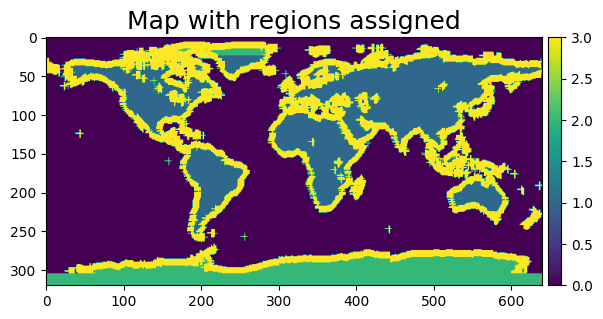

The map has a total area of 4.0pi square radians
The continent is 18.0 percent of the map area
The ocean is 61.0 percent of the map area
The poles are 2.0 percent of the map area
The coast is 19.0 percent of the map area


In [135]:
image0 = plt.imread('/Users/andrew/opt/anaconda3/envs/starry_stable/earth.png')

R = 50
wav_min = 0.41
wav_max = 2.4

wav = obs.wav_grid_from_R(R, wav_min, wav_max)
# _, contspec1 = obs.resample_to_R(R, regions['new_cont'][:,0], regions['new_cont'][:,1], wav_min = wav_min, wav_max = wav_max)
# _, contspec2 = obs.resample_to_R(R, regions['cont'][:,0], regions['cont'][:,1], wav_min = wav_min, wav_max = wav_max)
# _, contspec3 = obs.resample_to_R(R, regions['cont_warm'][:,0], regions['cont_warm'][:,1], wav_min = wav_min, wav_max = wav_max)
# _, contspec4 = obs.resample_to_R(R, regions['new_cont_warm'][:,0], regions['new_cont_warm'][:,1], wav_min = wav_min, wav_max = wav_max)
# _, contspec5 = obs.resample_to_R(R, regions['new_cont2'][:,0], regions['new_cont2'][:,1], wav_min = wav_min, wav_max = wav_max)
# _, contspec6 = obs.resample_to_R(R, regions['new_cont3'][:,0], regions['new_cont3'][:,1], wav_min = wav_min, wav_max = wav_max)
_, contspec = obs.resample_to_R(R, regions['cont_noveg'][:,0], regions['cont_noveg'][:,1], wav_min = wav_min, wav_max = wav_max)
_, seaspec = obs.resample_to_R(R, regions['sea'][:,0], regions['sea'][:,1], wav_min = wav_min, wav_max = wav_max)
_, snowspec = obs.resample_to_R(R, regions['snow'][:,0], regions['snow'][:,1], wav_min = wav_min, wav_max = wav_max)
# _, coastspec = obs.resample_to_R(R, regions['coast'][:,0], regions['coast'][:,1], wav_min = wav_min, wav_max = wav_max)
# _, coastspec = obs.resample_to_R(R, wav_deep, psb_spec * 2/3 + coast * 1/3, wav_min = wav_min, wav_max = wav_max)
_, coastspec = obs.resample_to_R(R, wav_deep, coast, wav_min = wav_min, wav_max = wav_max)
# roughness = np.linspace(0, 100, 11)

# for r in roughness:
#     earth_map = SpectralMap(
#         image0,
#         wav, 
#         1., contspec,
#         0., seaspec,
#         snow_id = 2., snow_spec = snowspec,
#         # coast_id = 3., coast_spec = coastspec, coast_size=1, 
#         roughness=r
#         )
#     exec("specmap{}, scalar_map{}, _, _, _, _, _, _, _ = earth_map.get_specmap(return_map_only=False)".format(int(r), int(r)))
    # spec_map, scalar_map, _, _, _, _, _, _, _ = earth_map.get_specmap(return_map_only=False)


earth_map = SpectralMap(
    image0,
    wav, 
    1., contspec, 
    0., seaspec,
    snow_id = 2., snow_spec = snowspec, snow_dims = (15, 41, 1 ,25),
    # ydeg = 5
    coast_id = 3., coast_spec = coastspec, coast_size=5, 
    )


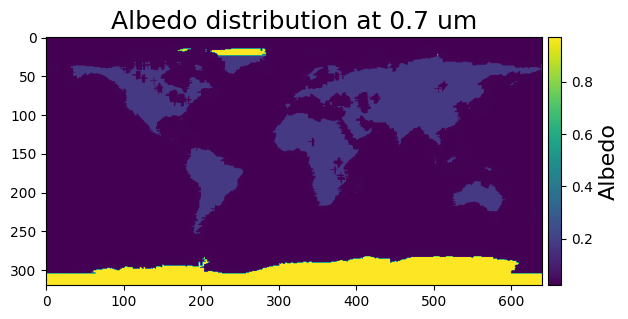

In [136]:
spec_map, scalar_map, _, _, _, _, _, _, _ = earth_map.get_specmap(return_map_only=False)


proxb_stellar_spec = obs.resample_to_R(
    R, 
    other_spec['prox_cen_muscles'][:,0], 
    other_spec['prox_cen_muscles'][:,1], 
    wav_min = wav_min, wav_max = wav_max, stack = True)

prox_Earth = Planet(
    spec_map,
    scalar_map,
    star_spec = proxb_stellar_spec[:,1] * 1E-7 * 100 ** 2 * 1E-6 * proxb_stellar_spec[:,0] / (h.value * c.value),
    phase_init = 0.,
    theta_init= 90.,
    obl = 23.5
    
)

Exposure time exceeds 30 minutes. Number of dithered exposures will be 17.


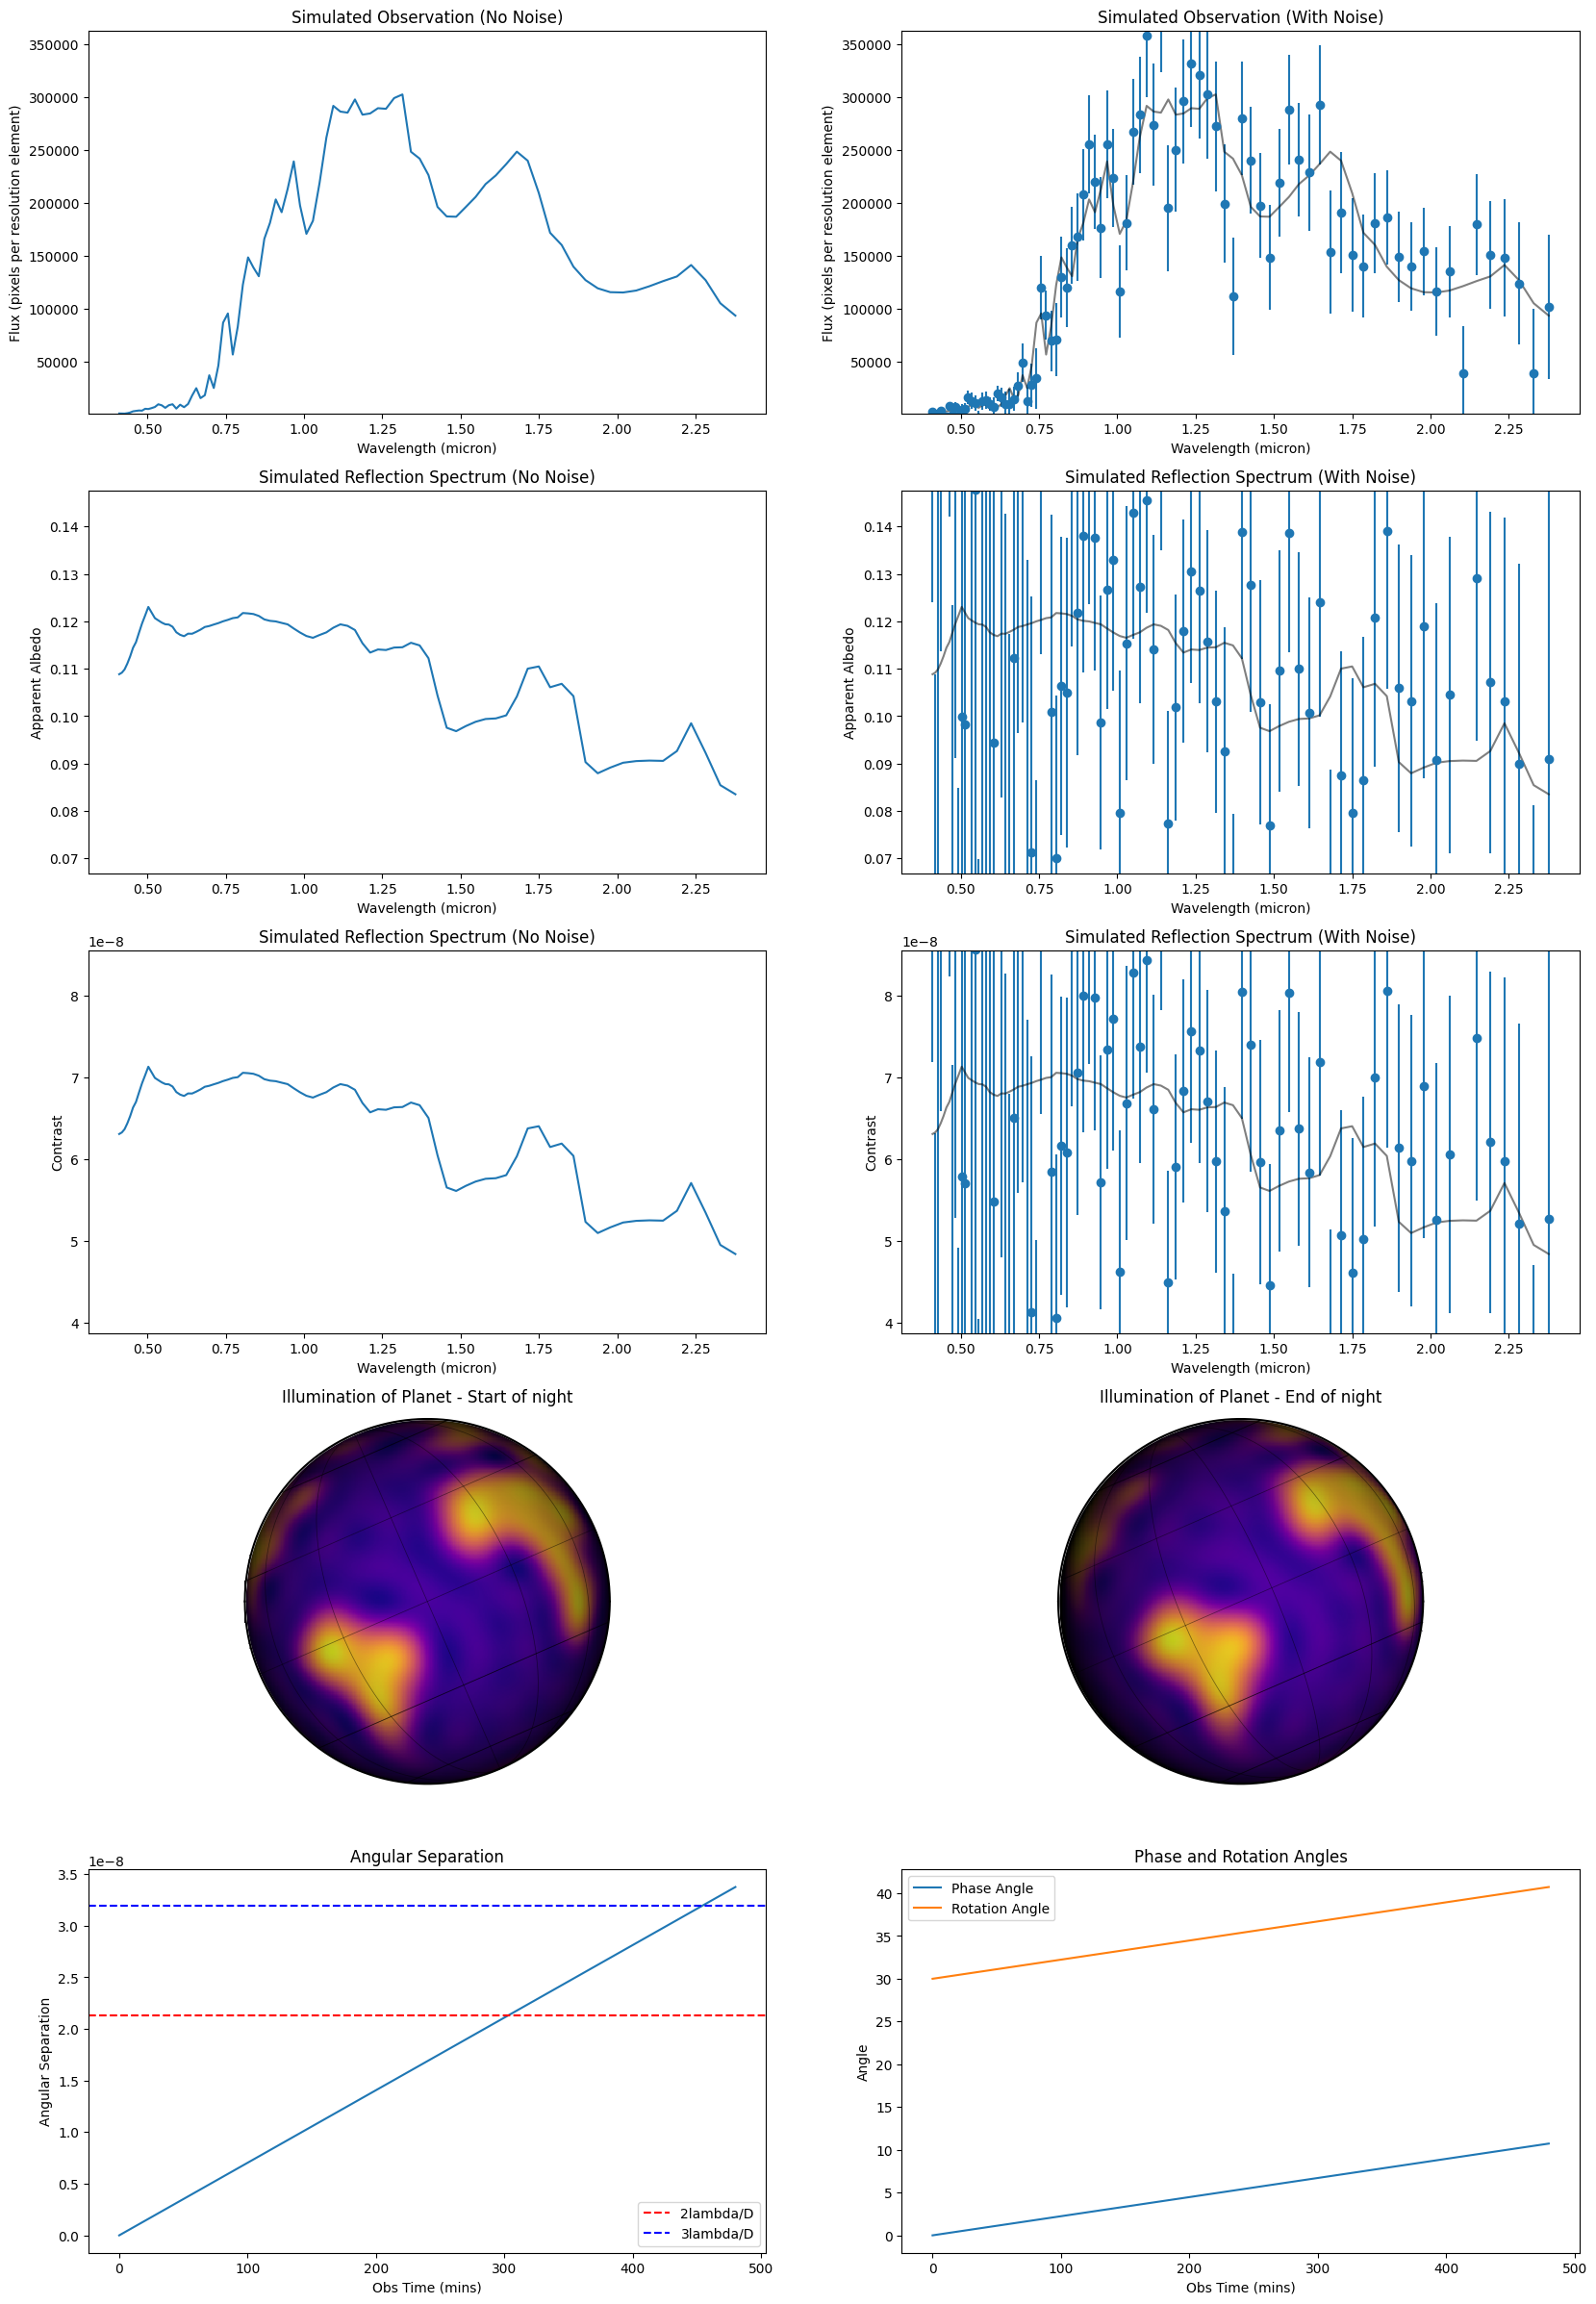

In [137]:
prox_Earth.obl = 23.5
prox_Earth.theta_init = 30.
prox_Earth.phase_init = 0.
obs_test = Observation(
    obs.Telescope(d_spec_aper=0.87, det_pix_size=10, read_noise=1, dar_curr=1, AO = 'No AO'),
    prox_Earth,
    wav,
    rpow = 50.,
    obs_per_night = 1,
    num_nights = 1,
    texp = 8*60,
    ndit = 1,
    cadence = 8*60,
)

_,_,_, alb_without, _, _, _, _, _, _= obs_test.generate_obs(if_plot = True)
    

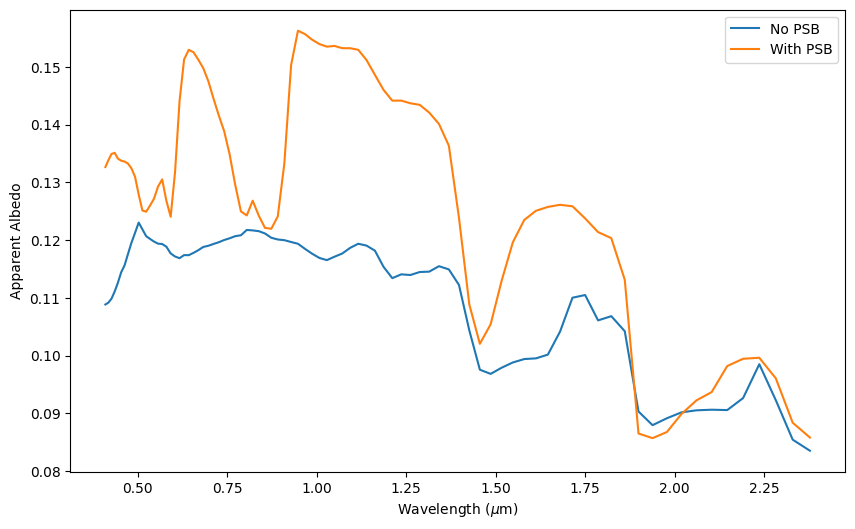

In [142]:
plt.figure(figsize=(10, 6))
plt.plot(obs_test.wav, alb_without[0][0], label = 'No PSB')
plt.plot(obs_test.wav, alb_with[0][0], label = 'With PSB')
plt.xlabel(r'Wavelength ($\mu$m)')
plt.ylabel('Apparent Albedo')
plt.legend()
plt.show()


Exposure time exceeds 30 minutes. Number of dithered exposures will be 3.


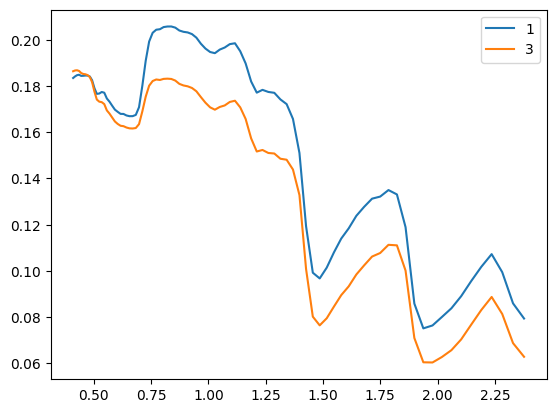

In [110]:
obls = np.linspace(0, 360, 100)
prox_Earth.phase_init = 0.
prox_Earth.theta_init = 0.
prox_Earth.prot = 1E6
prox_Earth.porb = 1E6

obs_test = Observation(
    obs.Telescope(d_spec_aper=0.87, det_pix_size=10, read_noise=1, dar_curr=1, AO = 'No AO'),
    prox_Earth,
    wav,
    rpow = 100.,
    obs_per_night = 1,
    num_nights = 1,
    texp = 60,
    ndit = 1,
    cadence = 60,
)

avg_albedo1 = np.zeros_like(wav)
for obl in obls:
    print(obl, end = '\r')
    prox_Earth.obl = obl
    obs_test.Planet = prox_Earth
    _, _, _, alb, _, _, _, _, _ , _ = obs_test.generate_obs(if_plot = False)
    avg_albedo1 += alb[0][0]

# prox_Earth.phase_init = 90.
# prox_Earth.theta_init = 0.

# avg_albedo2 = np.zeros_like(wav)
# for obl in obls:
#     print(obl, end = '\r')
#     prox_Earth.obl = obl
#     obs_test.Planet = prox_Earth
#     _, _, _, alb, _, _, _, _, _ , _ = obs_test.generate_obs(if_plot = False)
#     avg_albedo2 += alb[0][0]

p_inc = np.linspace(0, 360, 100)
prox_Earth.phase_init = 90.
prox_Earth.theta_init = 0.
prox_Earth.obl = 0.

avg_albedo3 = np.zeros_like(wav)
for inc in p_inc:
    print(inc, end = '\r')
    prox_Earth.p_inc = inc
    obs_test.Planet = prox_Earth
    _, _, _, alb, _, _, _, _, _ , _ = obs_test.generate_obs(if_plot = False)
    avg_albedo3 += alb[0][0]

avg_albedo1 = avg_albedo1 / len(obls)
# avg_albedo2 = avg_albedo2 / len(obls)
avg_albedo3 = avg_albedo3 / len(p_inc)
plt.plot(wav, avg_albedo1, label = "1")
# plt.plot(wav, avg_albedo2, label = "2")
plt.plot(wav, avg_albedo3, label = "3")
plt.legend()
plt.show()



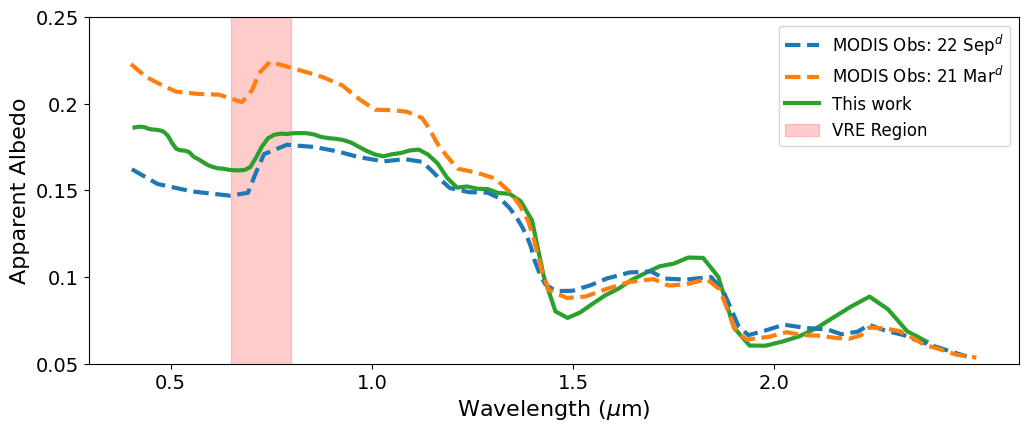

In [114]:
hamster_wav_sep = [0.40335153741022167, 0.46700487629289256, 0.552804009021423, 0.6468962142644221, 0.691871157880528, 0.7100433635734734, 0.7316492218741388, 0.7887811517500098, 0.8584075276013926, 0.9154044735909651, 0.9663187082042082, 1.0289343584609587, 1.081139376486932, 1.125093504462905, 1.1510441566038054, 1.1678580869408715, 1.1934459698873447, 1.2404962907552912, 1.2867451447983398, 1.3182891917277375, 1.340789318275131, 1.3590121429254383, 1.373868806911175, 1.3855280400902141, 1.395331244832648, 1.403843666162352, 1.4168443017114831, 1.4305873486352567, 1.456723603619818, 1.4983492595571404, 1.542952997485925, 1.5844521060298427, 1.6396267695543845, 1.693240681893599, 1.7258899093920663, 1.778229911304338, 1.8424822411824588, 1.8726933222346582, 1.888942007547849, 1.9105984848058764, 1.9348871478467258, 1.98144815212684, 2.0233690853154407, 2.075388500497753, 2.1333387701843094, 2.16590363275384, 2.206913424709925, 2.235116620453433, 2.2765819830257765, 2.320510801523068, 2.357859155563305, 2.3941951304563016, 2.438790431892193, 2.476965562236008]
hamster_alb_sep = [0.16228416353334785, 0.15377293019690708, 0.14945050392053283, 0.14700185409610228, 0.1486373947360244, 0.15936422112426588, 0.1709621619382037, 0.17638358037351232, 0.17505049563406982, 0.17250862310058732, 0.16931004837222793, 0.1667868203805558, 0.16811058284909317, 0.16652165356369703, 0.1608278176563811, 0.15674569880778516, 0.1514009301554748, 0.14904757465585283, 0.1487720497602105, 0.1453476689143698, 0.14015723563593424, 0.13445407745771315, 0.1286742694964938, 0.12323627813513151, 0.11710843872678496, 0.10959365256932145, 0.10187999129921382, 0.09582673005810882, 0.09191759112519811, 0.09210817977481538, 0.09531400515832324, 0.09926664802212486, 0.10266099043949328, 0.10330940617134335, 0.099176532736708, 0.0985384750836415, 0.1000414323151342, 0.09192173435671153, 0.0834073935966357, 0.07170483618698403, 0.0664988657903732, 0.06944263178065732, 0.07253658991330289, 0.07072392612618211, 0.06965497239572005, 0.06702194876894234, 0.06851972696104328, 0.07247029820908818, 0.06901277151114012, 0.06654962037641259, 0.06310452337300478, 0.06028298271236651, 0.05701915208767078, 0.05423593631853164]
hamster_wav_mar = [0.40108212082182687, 0.43750246064376064, 0.4766815336419215, 0.5136839914735178, 0.5676775459929471, 0.6200850398483682, 0.67655048678564, 0.7021299332392196, 0.7191463394057335, 0.7465311953385565, 0.8101001692922907, 0.8760397977491436, 0.9262453669593192, 0.968436267920517, 1.0077250153262955, 1.0499918447235361, 1.0868086997114719, 1.1245282594390296, 1.142472679823846, 1.1624081125315666, 1.1840561532967002, 1.2129511414574885, 1.2598327324675616, 1.3055585239512033, 1.3456403016889857, 1.3679463888998251, 1.3866247841663901, 1.3984105647388343, 1.41100624862907, 1.4217880865471684, 1.4394203566949195, 1.4838891107374057, 1.5303573135956896, 1.5825370221429818, 1.6399051738198753, 1.6993149567770347, 1.736494580959398, 1.7811405013526511, 1.831978807529851, 1.8628816809993307, 1.8770128065962126, 1.8898531487803645, 1.9045326464153343, 1.9314450587461123, 1.986223207104652, 2.0292746303410034, 2.068495885803632, 2.113445519941057, 2.151435047441212, 2.1848013768356402, 2.2152739891675433, 2.2354878261407545, 2.2741607095652956, 2.310496684458293, 2.3427409602978644, 2.370539204382477, 2.4064027356734288, 2.451926051327623, 2.5016085579783915]
hamster_alb_mar = [0.2229462519291922, 0.21572459940130306, 0.21092570150088563, 0.2069937747946511, 0.20574044726184187, 0.20529090664263594, 0.20096640875050498, 0.2078814621464011, 0.21767916886775843, 0.22425758470318927, 0.2201361051552158, 0.21561273215044074, 0.21065121241312162, 0.2026837782128171, 0.1966325885874688, 0.1963580994997048, 0.19544969599038772, 0.19183472649492972, 0.18566649057932738, 0.17705581968656453, 0.17030856716696188, 0.1625990491283677, 0.16029437659902843, 0.15694975295982103, 0.14841676765793482, 0.1410832478791834, 0.13306816651647452, 0.12506137161679254, 0.11388293299358836, 0.10364500792393028, 0.09259190205400702, 0.08797219891654497, 0.08877702163802659, 0.093155381539832, 0.09723542877267125, 0.09882850128958082, 0.09511409423780078, 0.09585573267870276, 0.09877878251141979, 0.09309530468288742, 0.08496835606931627, 0.07732512973493677, 0.06844722040955845, 0.06393316967568854, 0.06554385092653014, 0.06818826843996975, 0.06655065618429093, 0.06614047626446247, 0.06491097231285542, 0.06431020374340968, 0.06644500378069876, 0.07094455320427168, 0.07035414271360949, 0.06885636452150855, 0.06499280113524544, 0.06110748578353687, 0.05865158530395782, 0.05522824026599547, 0.05352951534549372]

plt.figure(figsize = (12, 4.5))
plt.plot(hamster_wav_sep, hamster_alb_sep, linestyle = 'dashed', label = r'MODIS Obs: 22 Sep$^d$', zorder = 10000, lw = 3)
plt.plot(hamster_wav_mar, hamster_alb_mar, linestyle = 'dashed', label = r'MODIS Obs: 21 Mar$^d$', zorder = 10000, lw = 3)
plt.plot(wav, avg_albedo3, label = 'This work', lw = 3)
plt.fill_betweenx([0, 0.3], 0.65, 0.8, color = 'red', alpha = 0.2, label = 'VRE Region')
plt.xlabel(r'Wavelength ($\mu$m)', fontsize = 16)
plt.ylabel('Apparent Albedo', fontsize = 16)
plt.legend(fontsize=12)
plt.tick_params(axis='both', which='major', labelsize=12)
plt.yticks([0.05, 0.1, 0.15, 0.2, 0.25], labels = ['0.05', '0.1', '0.15', '0.2', '0.25'], fontsize=14)
plt.xticks([0.5, 1., 1.5, 2.0], labels = ['0.5', '1.0', '1.5', '2.0'], fontsize=14)
plt.ylim(0.05, 0.25)
plt.show()

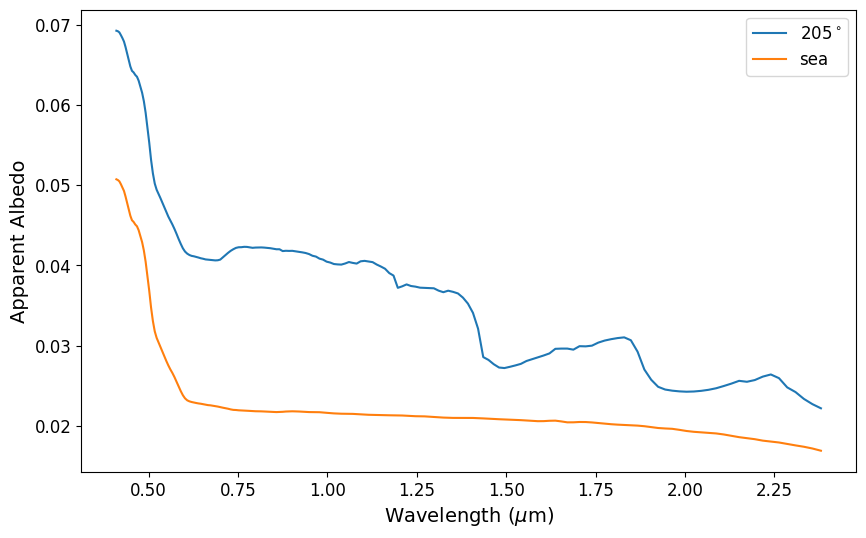

In [44]:
_, _, _, albedo_20, _ ,_, _, _ , _, ps = obs_test.generate_obs(if_plot = False)
prox_Earth.theta_init = 205.
obs_test.Planet = prox_Earth
_, _, _, albedo_205, _ ,_, _, _ , _, ps = obs_test.generate_obs(if_plot = False)

fig, ax = plt.subplots(figsize = (10, 6))
# ax.plot(obs_test.wav, albedo_20[0][0], label = r'$20^\circ$')
ax.plot(obs_test.wav, albedo_205[0][0], label = r'$205^\circ$')
ax.plot(obs_test.wav, seaspec, label = 'sea')
ax.set_xlabel(r'Wavelength ($\mu$m)', fontsize = 14)
ax.set_ylabel('Apparent Albedo', fontsize = 14)
ax.tick_params(axis = 'both', labelsize = 12)
ax.legend(fontsize = 12)



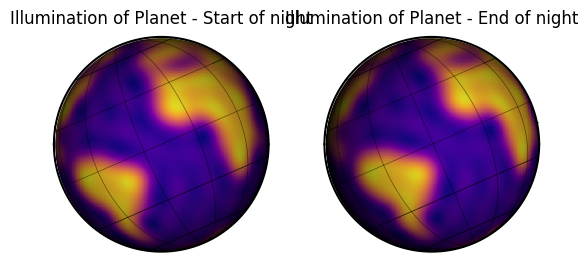

In [120]:
obs_test.viz_obs()

In [58]:
def gaussian_fit(wav, mu = 0.7, sigma = 0.02, A = 0.1):
    ### Fit a Gaussian to the reflectance spectra of a given region. ###
    return 1. - A * np.exp(-0.5 * ((wav - mu) / sigma) ** 2)

def reflectance_model(
        wav, 
        poly_coeffs, 
        smooth = 80, 
        edge_loc = 0.72,
        edge_size = 0.02,
        mu = (1.4, 1.9, 2.5), 
        sigma = (0.02, 0.02, 0.02), 
        A = (1e-4, 1e-4, 1e-4)
    ):
    ### Model the reflectance spectra of a given region with a polynomial and a Gaussian. ###
    poly = poly_coeffs[0] * (wav - wav[0]) ** 2 + poly_coeffs[1] * (wav - wav[0]) + poly_coeffs[2] 

    heaviside = H(wav, b = edge_size, smooth = smooth, edge_loc = edge_loc)

    gauss = np.ones_like(wav)

    for i in range(len(mu)):
        gauss *= gaussian_fit(wav, mu = mu[i], sigma = sigma[i], A = A[i])
  
    return poly * (1 + heaviside) * gauss

def bcl_reflectance_model(
        wav, 
        poly_coeffs, 
        # smooth = 80, 
        # edge_loc = 0.72,
        # edge_size = 0.02,
        Bcla_Qy_loc = 0.85,
        Bcla_Qy_gap = 0.015,
        Bcla_Qy_amp = (0.2, 0.1),
        Bcla_Qy_width = (0.02, 0.02),
        carot_Qx_soret_loc = 0.4,
        carot_Qx_soret_amp = 0.1,
        carot_Qx_soret_width = 0.04,
        mu = (1.4, 1.9, 2.5), 
        sigma = (0.02, 0.02, 0.02), 
        A = (1e-4, 1e-4, 1e-4)
    ):
    ### Model the reflectance spectra of a given region with a polynomial and a Gaussian. ###
    poly = poly_coeffs[0] * (wav - wav[0]) ** 2 + poly_coeffs[1] * (wav - wav[0]) + poly_coeffs[2] 

    # heaviside = H(wav, b = edge_size, smooth = smooth, edge_loc = edge_loc)

    gauss = np.ones_like(wav)

    for i in range(len(mu)):
        gauss *= gaussian_fit(wav, mu = mu[i], sigma = sigma[i], A = A[i])

    gauss *= gaussian_fit(wav, mu = Bcla_Qy_loc, sigma = Bcla_Qy_width[0], A = Bcla_Qy_amp[0]) * \
             gaussian_fit(wav, mu = Bcla_Qy_loc - Bcla_Qy_gap, sigma = Bcla_Qy_width[1], A = Bcla_Qy_amp[1]) * \
             gaussian_fit(wav, mu = carot_Qx_soret_loc, sigma = carot_Qx_soret_width, A = carot_Qx_soret_amp)
  
    return poly * gauss


def reflectance_model_short(
        wav, 
        poly_coeffs, 
        smooth = 80, 
        edge_loc = 0.72,
        edge_size = 0.02
    ):
    ### Model the reflectance spectra of a given region with a polynomial and a Gaussian. ###
    poly = poly_coeffs[0] * wav ** 2 + poly_coeffs[1] * wav + poly_coeffs[2] 

    heaviside = H(wav, b = edge_size, smooth = smooth, edge_loc = edge_loc)

    return poly * (1 + heaviside)

def H(wav, b = 0.1, smooth = 80, edge_loc = 0.72):
    ### Heaviside function to model the presence of a feature at a given wavelength, from Brandt 2014. ###
    return b * (1 + np.exp(smooth * (edge_loc - wav))) ** (-1)

def fit_poly(wav, refl, deg = 2):
    ### Fit a polynomial to the reflectance spectra of a given region. ###
    p = np.polyfit(wav, refl, deg)
    print(p)
    return np.polyval(p, wav)


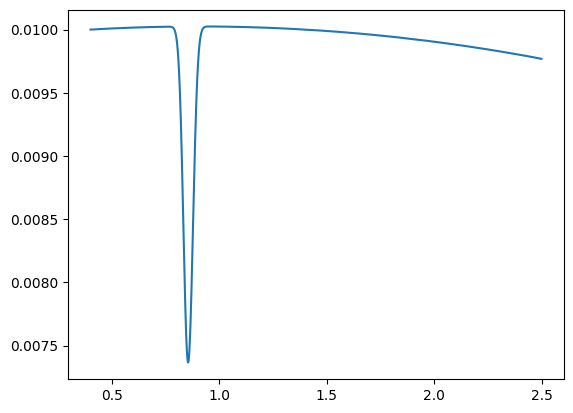

In [38]:
plt.plot(wav_deep, bcl_reflectance_model(wav_deep, poly_coeffs = [-0.0001, 0.0001, 0.01]))
plt.show()

In [65]:
prox_Earth.obl = 0.
prox_Earth.theta_init = 0.
prox_Earth.p_inc = 90.
prox_Earth.prot = 11.1868
prox_Earth.porb = 11.1868
prox_Earth.phase_init = 0.

num_nights = 50

num = 0
den = 0

for night in range(num_nights):
    obs_test = Observation(
        obs.Telescope(d_spec_aper=0.87, det_pix_size=10, read_noise=1, dar_curr=1, AO = 'No AO'),
        prox_Earth,
        wav,
        rpow = 50.,
        obs_per_night = 1,
        num_nights = 1,
        texp = 8*60,
        ndit = 1,
        cadence = 8*60,
    )
    _, _, _, albedo, albedo_noise ,albedo_err, _, _ , _, ps = obs_test.generate_obs(if_plot = False)

    num += albedo_noise.flatten() / albedo_err.flatten() ** 2
    den += 1 / albedo_err.flatten() ** 2

albedo_noise = num / den
albedo_err = 1 / np.sqrt(den)

index = np.where(np.logical_and(wav > 0.4, wav < 2.4))
wav_inf = wav[index]
alb1 = albedo_noise[index]
err1 = albedo_err[index]


Exposure time exceeds 30 minutes. Number of dithered exposures will be 17.
Exposure time exceeds 30 minutes. Number of dithered exposures will be 17.
Exposure time exceeds 30 minutes. Number of dithered exposures will be 17.
Exposure time exceeds 30 minutes. Number of dithered exposures will be 17.
Exposure time exceeds 30 minutes. Number of dithered exposures will be 17.
Exposure time exceeds 30 minutes. Number of dithered exposures will be 17.
Exposure time exceeds 30 minutes. Number of dithered exposures will be 17.
Exposure time exceeds 30 minutes. Number of dithered exposures will be 17.
Exposure time exceeds 30 minutes. Number of dithered exposures will be 17.
Exposure time exceeds 30 minutes. Number of dithered exposures will be 17.
Exposure time exceeds 30 minutes. Number of dithered exposures will be 17.
Exposure time exceeds 30 minutes. Number of dithered exposures will be 17.
Exposure time exceeds 30 minutes. Number of dithered exposures will be 17.
Exposure time exceeds 30 

In [110]:

data = theano.shared(alb1)
err = theano.shared(err1)

with pm.Model() as model:
    A = pm.Normal('a', mu = -0.02, sigma = .01)
    B = pm.Uniform('b', lower = -0.01, upper = 0.01)
    C = pm.Uniform('c', lower = 0., upper = 1.)

    # smooth = pm.Normal('smooth', mu = 80., sigma = 10.)
    # edge_loc = pm.Normal('edge_loc', mu = 0.7, sigma = 0.05)
    # # edge_size = pm.Normal('edge_size', mu = 0.5, sigma = 0.1)
    # edge_size = pm.Uniform('edge_size', lower = -0.1, upper = 1.)
    # smooth = pm.Uniform('smooth', lower = 0., upper = 1000.)
    # edge_loc = pm.Uniform('edge_loc', lower = wav_inf[0], upper = wav_inf[-1])
    # edge_size = pm.Uniform('edge_size', lower = -0.1, upper = 0.5)

    mu1 = pm.TruncatedNormal('mu1', mu = 1.45, sigma = 0.05, lower = 1.)
    sigma1 = pm.Normal('sigma1', mu = 0.1, sigma = 0.05)
    A1= pm.Normal('A1', mu = 0.3, sigma = 0.1)

    mu2 = pm.TruncatedNormal('mu2', mu = 1.95, sigma = 0.05, lower = 1.5)
    sigma2 = pm.Normal('sigma2', mu = 0.1, sigma = 0.05)
    A2= pm.Normal('A2', mu = 0.3, sigma = 0.1)

    mu3 = pm.TruncatedNormal('mu3', mu = 2.5, sigma = 0.05, lower = 2.)
    sigma3 = pm.Normal('sigma3', mu = 0.2, sigma = 0.05)
    A3= pm.Normal('A3', mu = 0.3, sigma = 0.1)

    # reflectance = reflectance_model(
    #     wav_inf, 
    #     (A, B, C), 
    #     smooth, 
    #     edge_loc,
    #     edge_size, 
    #     (mu1, mu2, mu3), 
    #     (sigma1, sigma2,sigma3),
    #     (A1, A2, A3)
    # )

    Bcla_Qy_loc = pm.TruncatedNormal('Bcla_Qy_loc', mu = 0.88, sigma = 0.05, lower = 0.7, upper = 1.)
    Bcla_Qy_gap = pm.Normal('Bcla_Qy_gap', mu = 0.08, sigma = 0.01)
    Bcla_Qy_amp = pm.TruncatedNormal('Bcla_Qy_amp', mu = np.array((0.3, 0.25)), sigma = np.array((0.1, 0.1)), lower = 0., shape = (2,))
    Bcla_Qy_width = pm.Normal('Bcla_Qy_width', mu = np.array((0.04, 0.03)), sigma = np.array((0.01, 0.01)), shape = (2,))

    carot_Qx_soret_loc = pm.TruncatedNormal('carot_Qx_soret_loc', mu = 0.4, sigma = 0.05, upper= 0.5)
    carot_Qx_soret_amp = pm.Normal('carot_Qx_soret_amp', mu = 0.8, sigma = 0.2)
    carot_Qx_soret_width = pm.Normal('carot_Qx_soret_width', mu = 0.06, sigma = 0.02)

    reflectance = bcl_reflectance_model(
        wav_inf,
        (A, B, C),
        Bcla_Qy_loc,
        Bcla_Qy_gap,
        Bcla_Qy_amp,
        Bcla_Qy_width,
        carot_Qx_soret_loc,
        carot_Qx_soret_amp,
        carot_Qx_soret_width,
        (mu1, mu2, mu3), 
        (sigma1, sigma2,sigma3),
        (A1, A2, A3)
    )
        

    # reflectance = reflectance_model_short(
    #     wav_inf,
    #     (A, B, C),
    #     smooth,
    #     edge_loc,
    #     edge_size
    # )

    pm.Deterministic('reflectance', reflectance)
    obb = pm.Normal('obs', mu = reflectance, sd = err, observed = data)

In [111]:
with model:
    soln = pmx.optimize()

optimizing logp for variables: [carot_Qx_soret_width, carot_Qx_soret_amp, carot_Qx_soret_loc, Bcla_Qy_width, Bcla_Qy_amp, Bcla_Qy_gap, Bcla_Qy_loc, A3, sigma3, mu3, A2, sigma2, mu2, A1, sigma1, mu1, c, b, a]


message: Desired error not necessarily achieved due to precision loss.
logp: -129726.8881478355 -> 263.0087190621354


In [97]:
soln

{'a': array(-0.00338264),
 'b_interval__': array(0.14441276),
 'c_interval__': array(-1.59308324),
 'smooth': array(79.79018515),
 'edge_loc': array(0.73753813),
 'edge_size_interval__': array(-0.29996593),
 'mu1': array(1.4978349),
 'sigma1': array(0.07498578),
 'A1': array(0.44394085),
 'mu2': array(1.97242048),
 'sigma2': array(0.08302424),
 'A2': array(0.46929015),
 'mu3': array(2.5192655),
 'sigma3': array(0.09043145),
 'A3': array(0.48999568),
 'b': array(-0.04639594),
 'c': array(0.16895055),
 'edge_size': array(0.36812239),
 'reflectance': array([0.16895055, 0.16851522, 0.16807029, 0.16761554, 0.16715073,
        0.16667562, 0.16618999, 0.16569358, 0.16518614, 0.1646674 ,
        0.16413712, 0.16359503, 0.16304091, 0.16247459, 0.16189613,
        0.16130626, 0.16070751, 0.16010791, 0.15953186, 0.15905356,
        0.15889915, 0.15974277, 0.16338313, 0.17300849, 0.18854622,
        0.20151975, 0.20720068, 0.20845286, 0.20805523, 0.20713659,
        0.20605228, 0.20490383, 0.20371

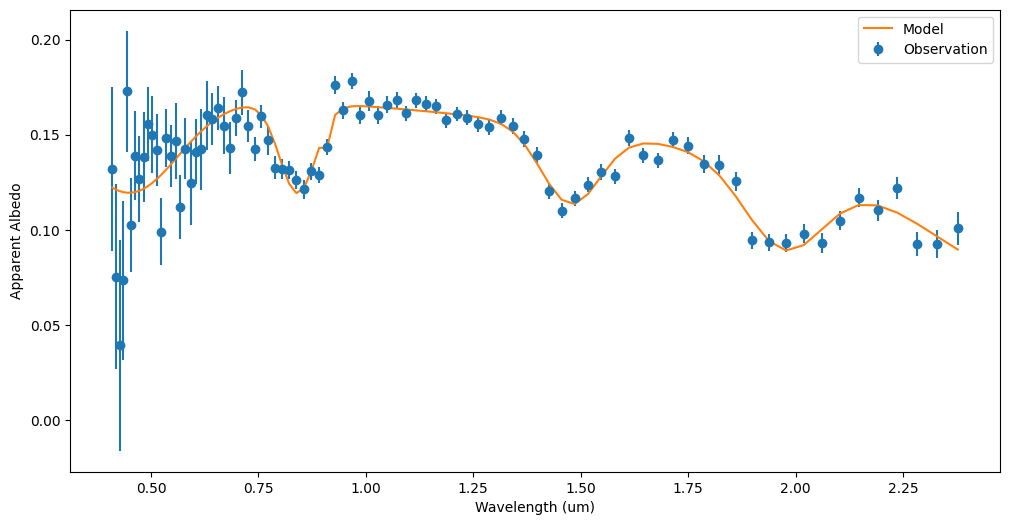

a -0.017096189349963303
b_interval__ 0.775035998970882
c_interval__ -1.5945388856265823
mu1_lowerbound__ -0.7409799860217224
sigma1 0.06796675809062167
A1 0.25987322979992056
mu2_lowerbound__ -0.7431475467361293
sigma2 0.09141513634806653
A2 0.32561189387370004
mu3_lowerbound__ -0.6550424885713685
sigma3 0.1821510295332918
A3 0.24933880901862274
Bcla_Qy_loc_interval__ 0.9458081291133252
Bcla_Qy_gap 0.07478325087060281
Bcla_Qy_amp_lowerbound__ [-1.12319825 -1.24964447]
Bcla_Qy_width [ 0.00356269 -0.04200778]
carot_Qx_soret_loc_upperbound__ -2.983201579667208
carot_Qx_soret_amp 0.2925836381161538
carot_Qx_soret_width 0.11456727247028503
b 0.00369218546503729
c 0.1687462654758145
mu1 1.4766465795817998
mu2 1.9756145380916086
mu3 2.5194199927047625
Bcla_Qy_loc 0.9160814134163188
Bcla_Qy_amp [0.32523794 0.28660668]
carot_Qx_soret_loc 0.44936952340070135
reflectance [0.12220458 0.12115937 0.1203388  0.11977242 0.11948749 0.11950788
 0.11985284 0.12053578 0.12156317 0.12293352 0.12463661 0.12

In [112]:

fig = plt.figure(figsize = (12, 6))
plt.errorbar(wav_inf, alb1, yerr = err1, fmt = 'o', label = 'Observation')
# plt.plot(wav_inf, bcl_reflectance_model(wav_inf, (-0.018, -0.002, 0.18), 0.88, 0.08, (0.3, 0.25), (0.04, 0.03), 0.4, 0.8, .06, (1.45, 1.95, 2.5), (0.08, 0.08, 0.08), (0.3, 0.3, 0.3)), label = 'Model')
plt.plot(wav_inf, soln['reflectance'], label = 'Model')
plt.xlabel('Wavelength (um)')
plt.ylabel('Apparent Albedo')
# plt.xlim(0.6, 1.0)
plt.legend()
plt.show()

# plt.plot(wav, reflectance_model(wav, (0, -0.1, 0.5), 80, 0.72, 0.5, (1.4, 1.9), (0.1, 0.1), (0.5, 0.5)), label = 'Model')
# plt.show()

for key in soln.keys():
    print(key, soln[key])


In [113]:
with model:
    trace = pmx.sample(
        tune=2000,
        draws=2500,
        start=soln,
        chains=5,
        target_accept=0.95
    )

/Users/andrew/opt/anaconda3/envs/starry_spot/lib/python3.9/site-packages/deprecat/classic.py:215: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)


Got error No model on context stack. trying to find log_likelihood in translation.
/Users/andrew/opt/anaconda3/envs/starry_spot/lib/python3.9/site-packages/arviz/data/io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(
Got error No model on context stack. trying to find log_likelihood in translation.
/Users/andrew/opt/anaconda3/envs/starry_spot/lib/python3.9/site-packages/arviz/data/io_pymc3_3x.py:98: FutureWarning: Using `from_pymc3` without the model will be deprecated in a future release. Not using the model will return less accurate and less useful results. Make sure you use the model argument or call from_pymc3 within a model context.
  warnings.warn(
Got error No model on context stack. trying to find log_likelihood in translation.


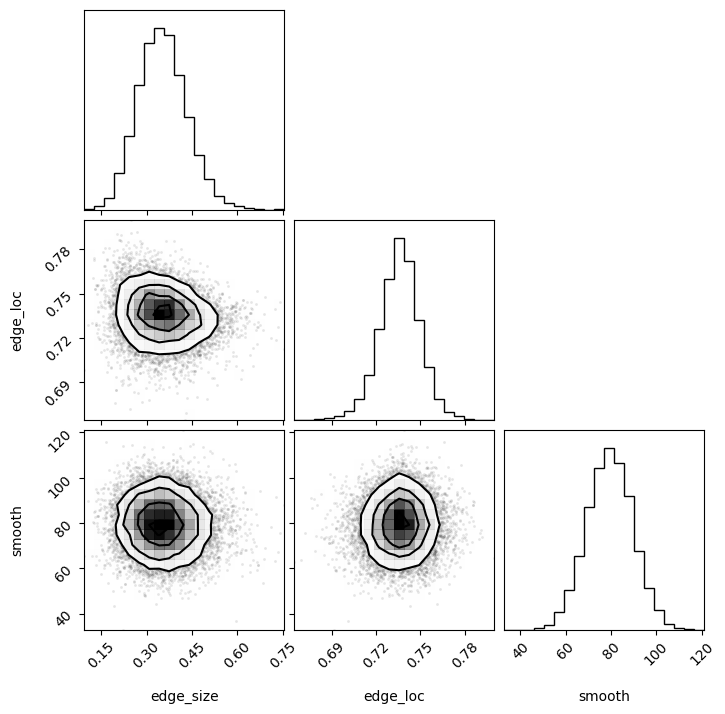

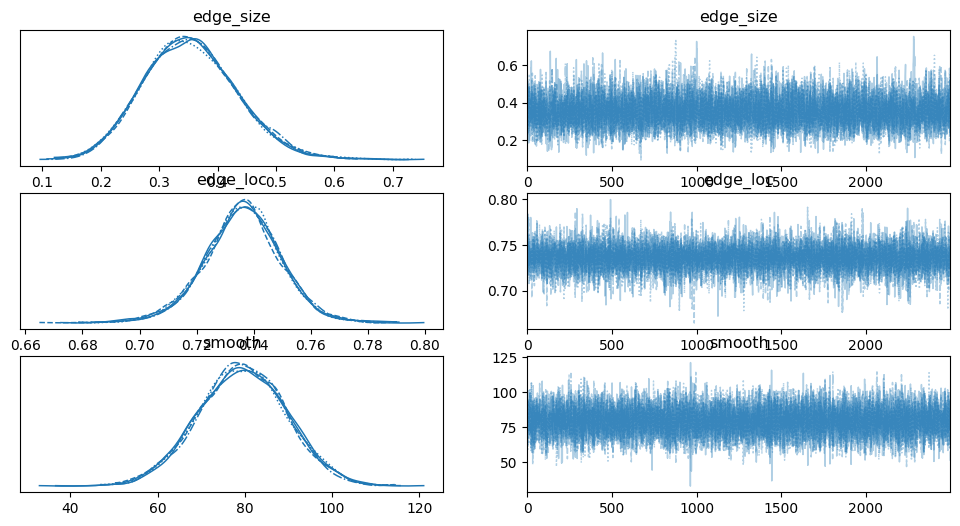

In [100]:
# var_names = ["A2", "sigma2", "mu2", "A1", "sigma1", "mu1", "edge_size", "edge_loc", "smooth", "a", "b", "c"]
var_names = ["edge_size", "edge_loc", "smooth"]
pm.summary(trace, var_names=var_names)

samples = pm.trace_to_dataframe(trace, varnames=var_names)
corner_fig = corner(np.array(samples), labels=var_names)
plt.savefig('corner_plot.png')

_ = az.plot_trace(trace, var_names=var_names)
plt.savefig('trace_plot.png')

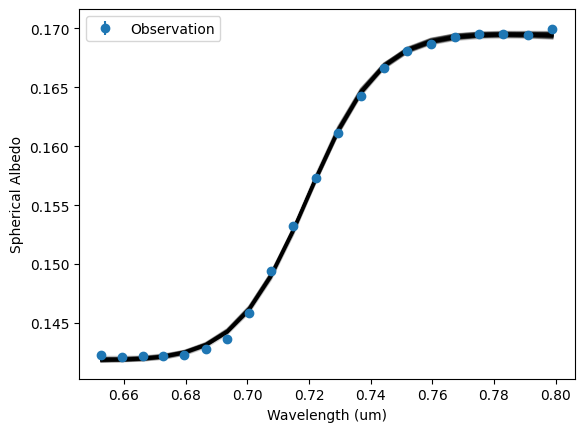

In [59]:
num_samp = 100
for i in range(num_samp):
    rand = np.random.randint(0, len(trace['reflectance']))
    plt.plot(wav_inf, trace['reflectance'][rand], color = 'black', alpha = 0.1)
plt.errorbar(wav_inf, alb1, yerr = err1, fmt = 'o', label = 'Observation')
plt.xlabel('Wavelength (um)')
plt.ylabel('Spherical Albedo')
plt.legend()
plt.show()

In [114]:
mean_vals = dict.fromkeys(trace.varnames)

for var in trace.varnames:
    mean_vals[var] = dict.fromkeys(['mean', 'median', 'q1', 'q3'])
    if var == 'reflectance':
        mean_vals[var]['mean'] = np.mean(trace[var], axis=0)
        mean_vals[var]['median'] = np.median(trace[var], axis = 0)
        mean_vals[var]['q1'] = np.quantile(trace[var], 0.16, axis = 0)
        mean_vals[var]['q3'] = np.quantile(trace[var], 0.84, axis = 0)
    else:
        mean_vals[var]['mean'] = np.mean(trace[var])
        mean_vals[var]['median'] = np.median(trace[var])
        mean_vals[var]['q1'] = np.quantile(trace[var], 0.16)
        mean_vals[var]['q3'] = np.quantile(trace[var], 0.84)
        print("{0}: {1:.4f} +{2:.4f} -{3:.4f}".format(var, mean_vals[var]['median'], mean_vals[var]['q3'] - mean_vals[var]['median'], mean_vals[var]['median'] - mean_vals[var]['q1']))

a: -0.0168 +0.0033 -0.0032
b_interval__: 0.0805 +1.5950 -1.5244
c_interval__: -1.5720 +0.0245 -0.0237
mu1_lowerbound__: -0.7426 +0.0116 -0.0116
sigma1: 0.0685 +0.0074 -0.0065
A1: 0.2580 +0.0166 -0.0165
mu2_lowerbound__: -0.7461 +0.0178 -0.0175
sigma2: 0.0892 +0.0097 -0.0089
A2: 0.3165 +0.0245 -0.0245
mu3_lowerbound__: -0.6522 +0.0854 -0.0953
sigma3: 0.1777 +0.0457 -0.0422
A3: 0.2341 +0.0886 -0.0826
Bcla_Qy_loc_interval__: 0.2416 +0.1122 -0.1131
Bcla_Qy_gap: 0.0752 +0.0069 -0.0060
Bcla_Qy_amp_lowerbound__: -1.5206 +0.1814 -0.2631
Bcla_Qy_width: 0.0361 +0.0080 -0.0066
carot_Qx_soret_loc_upperbound__: -3.1319 +0.6599 -0.9954
carot_Qx_soret_amp: 0.3110 +0.0656 -0.0463
carot_Qx_soret_width: 0.1047 +0.0144 -0.0143
b: 0.0004 +0.0064 -0.0066
c: 0.1719 +0.0035 -0.0033
mu1: 1.4759 +0.0056 -0.0055
mu2: 1.9742 +0.0085 -0.0082
mu3: 2.5209 +0.0464 -0.0473
Bcla_Qy_loc: 0.8680 +0.0082 -0.0084
Bcla_Qy_amp: 0.2186 +0.0435 -0.0506
carot_Qx_soret_loc: 0.4564 +0.0275 -0.0408


Running theta =  0.0


optimizing logp for variables: [edge_size, edge_loc, smooth, c, b]


message: Desired error not necessarily achieved due to precision loss.
logp: -3718526.0496365735 -> 119.57611071548246



Running theta =  5.0


optimizing logp for variables: [edge_size, edge_loc, smooth, c, b]


...

optimizing logp for variables: [edge_size, edge_loc, smooth, c, b]


message: Desired error not necessarily achieved due to precision loss.
logp: -48933167.867534146 -> 139.9022557343877


Running theta =  165.0


optimizing logp for variables: [edge_size, edge_loc, smooth, c, b]


message: Desired error not necessarily achieved due to precision loss.
logp: -62825541.08078498 -> 142.46926564177426
There were 8 divergences after tuning. Increase `target_accept` or reparameterize.
There were 8 divergences after tuning. Increase `target_accept` or reparameterize.
There were 2 divergences after tuning. Increase `target_accept` or reparameterize.


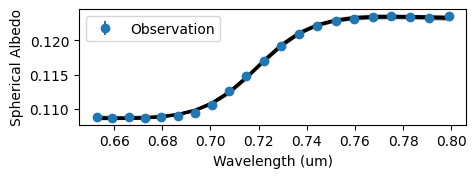

Running theta =  170.0


optimizing logp for variables: [edge_size, edge_loc, smooth, c, b]


message: Optimization terminated successfully.
logp: -80197922.85334079 -> 145.0885206878532
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


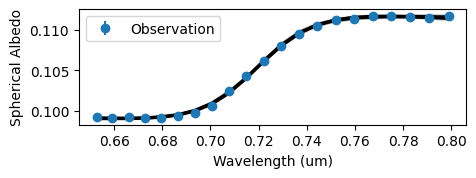

Running theta =  175.0


optimizing logp for variables: [edge_size, edge_loc, smooth, c, b]


message: Desired error not necessarily achieved due to precision loss.
logp: -102141707.292589 -> 147.7899290819494
There were 5 divergences after tuning. Increase `target_accept` or reparameterize.
There were 7 divergences after tuning. Increase `target_accept` or reparameterize.
There were 10 divergences after tuning. Increase `target_accept` or reparameterize.


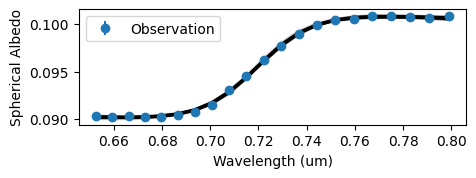

Running theta =  180.0


optimizing logp for variables: [edge_size, edge_loc, smooth, c, b]


message: Optimization terminated successfully.
logp: -129678324.5790236 -> 150.55442678504434
There were 6 divergences after tuning. Increase `target_accept` or reparameterize.
There were 7 divergences after tuning. Increase `target_accept` or reparameterize.


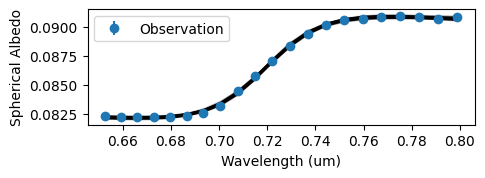

Running theta =  185.0


optimizing logp for variables: [edge_size, edge_loc, smooth, c, b]


message: Optimization terminated successfully.
logp: -162684242.99844122 -> 153.26335254345472
There were 8 divergences after tuning. Increase `target_accept` or reparameterize.
There were 5 divergences after tuning. Increase `target_accept` or reparameterize.


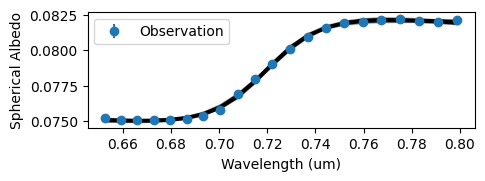

Running theta =  190.0


optimizing logp for variables: [edge_size, edge_loc, smooth, c, b]


message: Desired error not necessarily achieved due to precision loss.
logp: -198838043.29010117 -> 155.72133498747706
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.


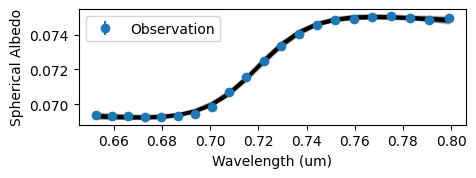

Running theta =  195.0


optimizing logp for variables: [edge_size, edge_loc, smooth, c, b]


message: Optimization terminated successfully.
logp: -233112375.62021098 -> 157.7099198937495
There were 6 divergences after tuning. Increase `target_accept` or reparameterize.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.


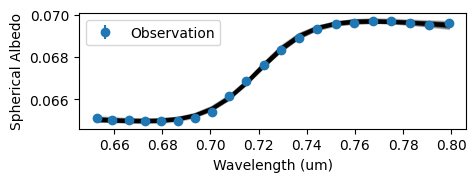

Running theta =  200.0


optimizing logp for variables: [edge_size, edge_loc, smooth, c, b]


message: Desired error not necessarily achieved due to precision loss.
logp: -258683015.876238 -> 159.0461321907429
There were 6 divergences after tuning. Increase `target_accept` or reparameterize.
There were 7 divergences after tuning. Increase `target_accept` or reparameterize.
There were 10 divergences after tuning. Increase `target_accept` or reparameterize.


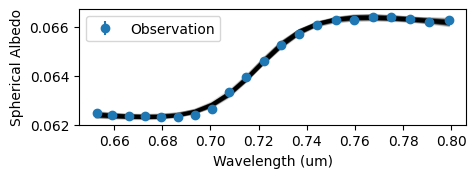

Running theta =  205.0


optimizing logp for variables: [edge_size, edge_loc, smooth, c, b]


message: Optimization terminated successfully.
logp: -270251793.3743242 -> 159.65735786217317
There were 14 divergences after tuning. Increase `target_accept` or reparameterize.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


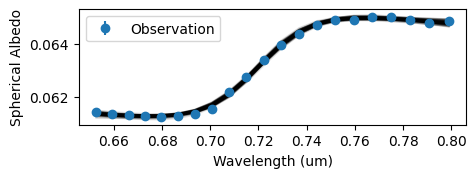

Running theta =  210.0


optimizing logp for variables: [edge_size, edge_loc, smooth, c, b]


message: Optimization terminated successfully.
logp: -267051697.70843032 -> 159.6011124911261
There were 31 divergences after tuning. Increase `target_accept` or reparameterize.
There were 14 divergences after tuning. Increase `target_accept` or reparameterize.
There were 23 divergences after tuning. Increase `target_accept` or reparameterize.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


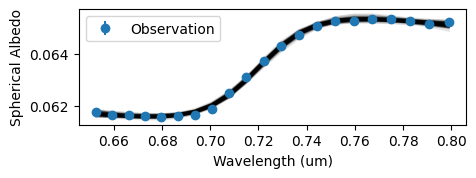

Running theta =  215.0


optimizing logp for variables: [edge_size, edge_loc, smooth, c, b]


message: Optimization terminated successfully.
logp: -251377661.82264236 -> 158.96419567067457
There were 2 divergences after tuning. Increase `target_accept` or reparameterize.
There were 2 divergences after tuning. Increase `target_accept` or reparameterize.


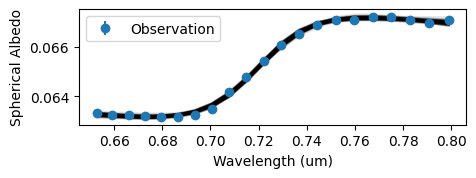

Running theta =  220.0


optimizing logp for variables: [edge_size, edge_loc, smooth, c, b]


message: Optimization terminated successfully.
logp: -225602647.88137916 -> 157.75690616175177
There were 5 divergences after tuning. Increase `target_accept` or reparameterize.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.


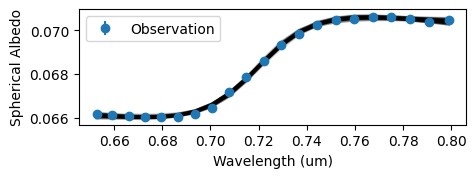

Running theta =  225.0


optimizing logp for variables: [edge_size, edge_loc, smooth, c, b]


message: Desired error not necessarily achieved due to precision loss.
logp: -192377781.8108969 -> 155.9397989782159
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.


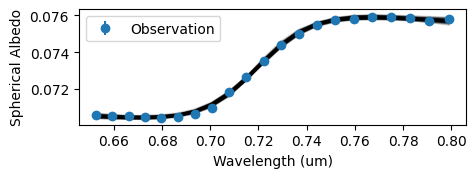

Running theta =  230.0


optimizing logp for variables: [edge_size, edge_loc, smooth, c, b]


message: Desired error not necessarily achieved due to precision loss.
logp: -155893979.0410273 -> 153.5265929565319
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


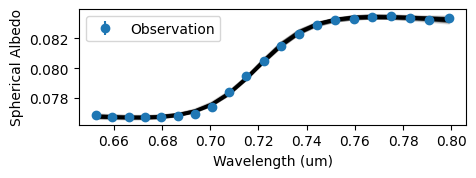

Running theta =  235.0


optimizing logp for variables: [edge_size, edge_loc, smooth, c, b]


message: Optimization terminated successfully.
logp: -120871374.39049916 -> 150.6267909306467
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


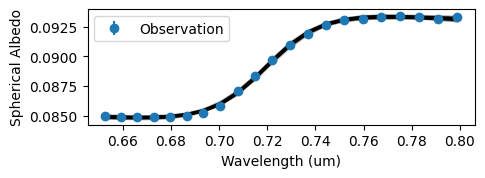

Running theta =  240.0


optimizing logp for variables: [edge_size, edge_loc, smooth, c, b]


message: Desired error not necessarily achieved due to precision loss.
logp: -90619222.84652103 -> 147.40756919294589
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.


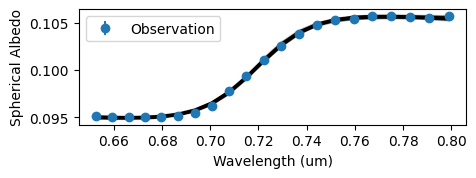

Running theta =  245.0


optimizing logp for variables: [edge_size, edge_loc, smooth, c, b]


message: Optimization terminated successfully.
logp: -66411693.93581651 -> 144.04151069868777
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.


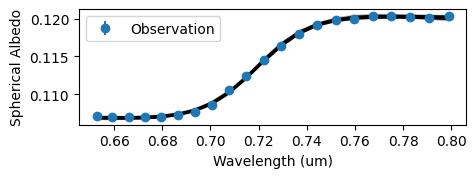

Running theta =  250.0


optimizing logp for variables: [edge_size, edge_loc, smooth, c, b]


message: Optimization terminated successfully.
logp: -48069706.44368728 -> 140.68351536254858
There were 4 divergences after tuning. Increase `target_accept` or reparameterize.


Running theta =  255.0


optimizing logp for variables: [edge_size, edge_loc, smooth, c, b]


...

optimizing logp for variables: [edge_size, edge_loc, smooth, c, b]


message: Desired error not necessarily achieved due to precision loss.
logp: -4347525.15190111 -> 120.48099012585125



Running theta =  360.0


optimizing logp for variables: [edge_size, edge_loc, smooth, c, b]


message: Desired error not necessarily achieved due to precision loss.
logp: -3718526.0496365745 -> 119.57611071548234


In [142]:
theta_init = np.linspace(0, 360, 73)
edge_locs = np.zeros((73, 4))
edge_sizes = np.zeros((73, 4))
smooths = np.zeros((73, 4))
prox_Earth.obl = -23.5

for i, theta in enumerate(theta_init):
    print("Running theta = ", theta)
    prox_Earth.theta_init = theta
    obs_test.Planet = prox_Earth
    _, _, _, albedo, _ ,_, _, _ , _, _ = obs_test.generate_obs(if_plot = False)
    index = np.where(np.logical_and(wav > 0.65, wav < 0.8))
    wav_inf = wav[index]
    data.set_value(albedo.flatten()[index])
    err.set_value(albedo.flatten()[index] * 0.0015)
    with model:
        soln = pmx.optimize()
        trace = pmx.sample(
            tune=500,
            draws=2000,
            chains=4,
            target_accept=0.95,
            start=soln,
            progressbar=False,
            return_inferencedata=False
        )
    if theta > 160 and theta < 250:
        num_samp = 100
        plt.figure(figsize = (5, 1.5))
        for num in range(num_samp):
            rand = np.random.randint(0, len(trace['reflectance']))
            plt.plot(wav_inf, trace['reflectance'][rand], color = 'black', alpha = 0.1)
        plt.errorbar(wav_inf, albedo.flatten()[index], yerr = albedo.flatten()[index] * 0.0015, fmt = 'o', label = 'Observation')
        plt.xlabel('Wavelength (um)')
        plt.ylabel('Spherical Albedo')
        plt.legend()
        plt.show()

    edge_locs[i] = np.array([theta, np.median(trace['edge_loc']), np.quantile(trace['edge_loc'], 0.16), np.quantile(trace['edge_loc'], 0.84)])
    edge_sizes[i] = np.array([theta, np.median(trace['edge_size']), np.quantile(trace['edge_size'], 0.16), np.quantile(trace['edge_size'], 0.84)])
    smooths[i] = np.array([theta, np.median(trace['smooth']), np.quantile(trace['smooth'], 0.16), np.quantile(trace['smooth'], 0.84)])

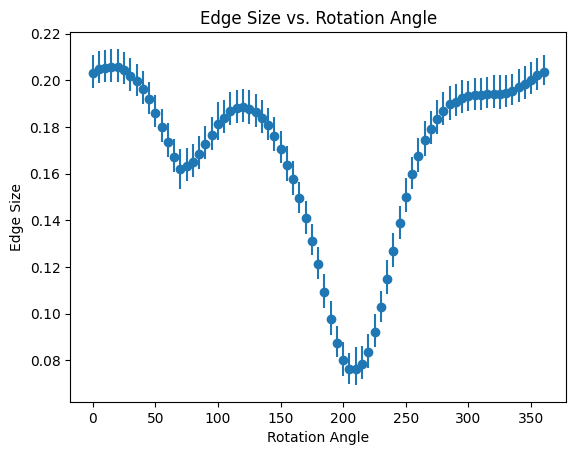

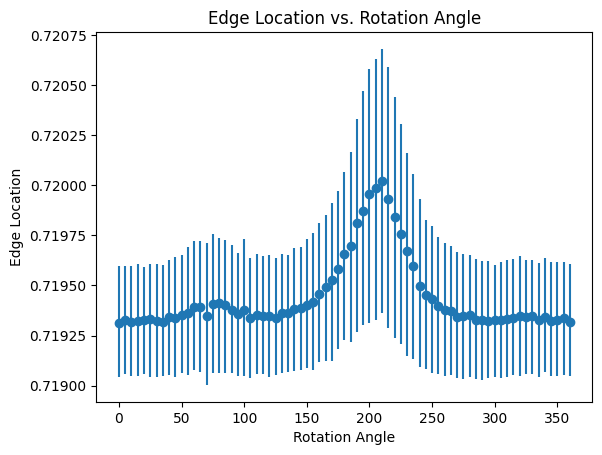

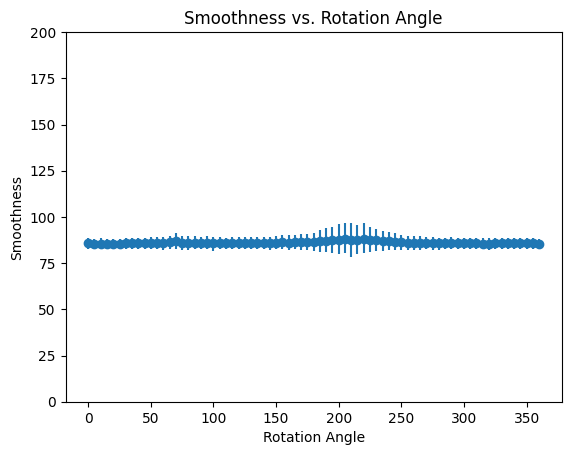

In [143]:
# idx = np.where(edge_sizes[:,1] < 0)
# edge_sizes[idx, 1] = 0.0987
# edge_sizes[idx, 2] = 0.0987 - 0.0071
# edge_sizes[idx, 3] = 0.0987 + 0.0077

## RENAME THE FILE BEFORE RUNNING! ##
np.savetxt('edge_locs_neg235obl_quad_0.4correct.txt', edge_sizes)


plt.errorbar(theta_init, edge_sizes[:,1], yerr = [edge_sizes[:,1] - edge_sizes[:,2], edge_sizes[:,3] - edge_sizes[:,1]], fmt = 'o', label = 'Edge')
plt.title('Edge Size vs. Rotation Angle')
plt.xlabel('Rotation Angle')
plt.ylabel('Edge Size')
plt.show()

plt.errorbar(theta_init, edge_locs[:,1], yerr = [edge_locs[:,1] - edge_locs[:,2], edge_locs[:,3] - edge_locs[:,1]], fmt = 'o', label = 'Edge')
plt.title('Edge Location vs. Rotation Angle')
plt.xlabel('Rotation Angle')
plt.ylabel('Edge Location')
plt.show()

plt.errorbar(theta_init, smooths[:,1], yerr = [smooths[:,1] - smooths[:,2], smooths[:,3] - smooths[:,1]], fmt = 'o', label = 'Edge')
plt.title('Smoothness vs. Rotation Angle')
plt.xlabel('Rotation Angle')
plt.ylim(0, 200)
plt.ylabel('Smoothness')
plt.show()



/var/folders/9n/l_gsk58x7zx9nz635n3gcs_00000gn/T/ipykernel_10031/523900324.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


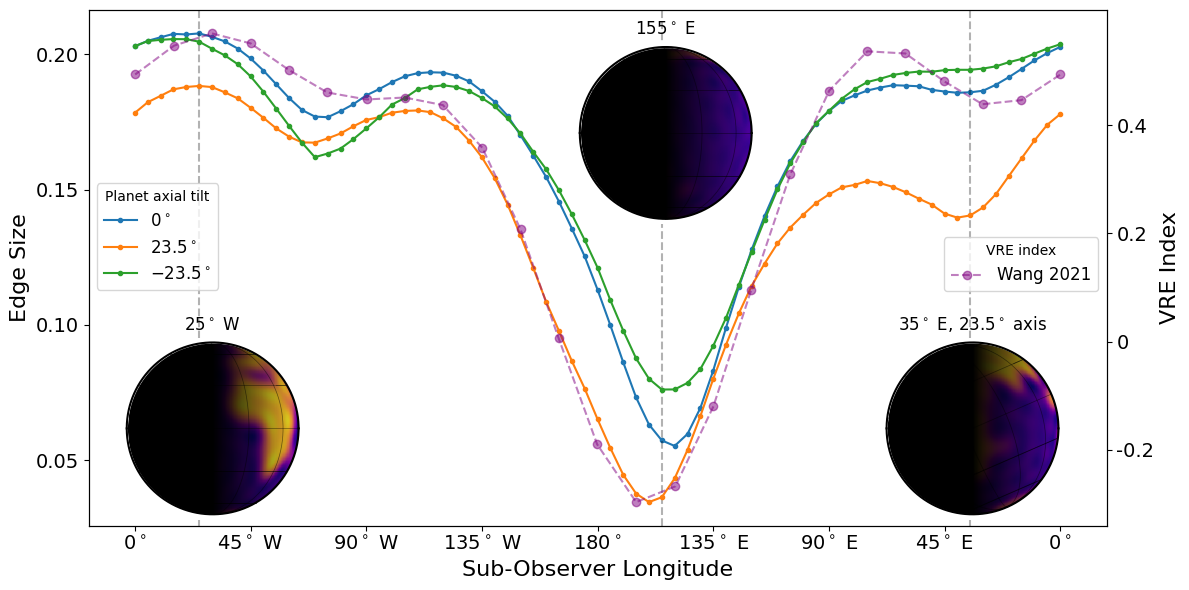

In [16]:
angle = np.asarray([-180.15368621606984, -164.97574935865256, -149.743737721507, -134.9258250554385, -120.18190945636664, -105.0139337425835, -89.82745876205121, -75.00812307546357, -60.19305645043343, -45.08057853689775, -30.210014111620154, -15.069075787701166, 0.1031689876394637, 15.198570654945172, 30.010791238937003, 45.04500302391858, 59.86291568998706, 74.83736061316372, 90.1590225430167, 104.96412802441267, 119.80907808034533, 135.13074001019828, 150.03545692793585, 164.83913938881267])
VRE_index = np.asarray([-0.18983068172691497, -0.29658807981834245, -0.2675053482378196, -0.11962675506165989, 0.09610765108315505, 0.30917852527361805, 0.4641949168011332, 0.5366710231379737, 0.5326874073641401, 0.4811165222216544, 0.4388679989194005, 0.44643219602660617, 0.49384423302984065, 0.5471148721168801, 0.5697432115711774, 0.5512795613349786, 0.5023546849103029, 0.4605851300735246, 0.4476821868999205, 0.4512919736275291, 0.4373142719460285, 0.3586057344791584, 0.20763136951394923, 0.006587276670000947])
angle = np.append(angle[12:], angle[:13]+360)
VRE_index = np.append(VRE_index[12:], VRE_index[:13])

th, ed, eder1, eder2 = np.loadtxt('edge_locs_0obl_quad_0.4correct.txt', unpack = True)
th1, ed1, eder11, eder21 = np.loadtxt('edge_locs_235obl_quad_0.4correct.txt', unpack = True)
th2, ed2, eder12, eder22 = np.loadtxt('edge_locs_neg235obl_quad_0.4correct.txt', unpack = True)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(th, ed, '.-', label = r'$0^\circ$')
ax.axvline(25, color = 'black', linestyle = '--', alpha = 0.3)
# plt.axvline(70, color = 'blue', linestyle = '--', label = '70 deg')
# plt.axvline(115, color = 'green', linestyle = '--', label = '115 deg')
ax.axvline(205, color = 'black', linestyle = '--', alpha = 0.3)
# plt.axvline(290, color = 'orange', linestyle = '--', label = '290 deg')
ax.axvline(325, color = 'black', linestyle = '--', alpha = 0.3)
ax.plot(th1, ed1, '.-', label = r'$23.5^\circ$')
ax.plot(th2, ed2, '.-', label = r'$-23.5^\circ$')

# plt.title('Edge Size vs. Rotation Angle', fontsize=14)
ax.set_xlabel('Sub-Observer Longitude', fontsize=16)
ax.set_ylabel('Edge Size', fontsize=16)
ax.set_xticks([0, 45, 90, 135, 180, 225, 270, 315, 360], labels=[r'$0^\circ$', r'$45^\circ$ W', r'$90^\circ$ W', r'$135^\circ$ W', r'$180^\circ$', r'$135^\circ$ E', r'$90^\circ$ E', r'$45^\circ$ E', r'$0^\circ$'],  fontsize=14)
ax.set_yticks([0.05, 0.10, 0.15, 0.20], labels = ['0.05', '0.10', '0.15', '0.20'], fontsize=14)
ax.legend(fontsize=12, loc=2, bbox_to_anchor=(0., -0.32, 1.0, 1.0), title='Planet axial tilt')

ax2 = ax.twinx()
ax2.plot(angle, VRE_index, 'o--', color = 'purple', label = 'Wang 2021', alpha = 0.5)
ax2.set_ylabel('VRE Index', fontsize=16)
ax2.legend(fontsize=12, loc=1, bbox_to_anchor=(0., -0.425, 1.0, 1.0), title='VRE index')
ax2.set_yticks([-0.2, 0, 0.2, 0.4], labels = ['-0.2', '0', '0.2', '0.4'], fontsize=14)

axins1 = inset_axes(ax, width="50%", height="50%", bbox_to_anchor=(.35, .0, .7, .7),
                   bbox_transform=ax.transAxes, loc=4)
prox_Earth.obl = 23.5
prox_Earth.theta_init = 325.
obs_test.Planet = prox_Earth
obs_test.viz_obs(num_maps = 1, projection='ortho', ax = axins1, title = r'$35^\circ$ E, $23.5^\circ$ axis')


axins2 = inset_axes(ax, width="50%", height="50%", bbox_to_anchor=(-.06, .0, .7, .7),
                   bbox_transform=ax.transAxes, loc=3)
prox_Earth.obl = 0.
prox_Earth.theta_init = 25.
obs_test.Planet = prox_Earth
obs_test.viz_obs(num_maps = 1, projection='ortho', ax = axins2, title = r'$25^\circ$ W')


axins3 = inset_axes(ax, width="50%", height="50%", bbox_to_anchor=(0.385, .25, .7, .7),
                   bbox_transform=ax.transAxes, loc=2)
prox_Earth.obl = 0.
prox_Earth.theta_init = 205.
obs_test.Planet = prox_Earth
obs_test.viz_obs(num_maps = 1, projection='ortho', ax = axins3, title = r'$155^\circ$ E')


plt.tight_layout()
plt.tick_params(axis='both', which='major', labelsize=14)
plt.show()

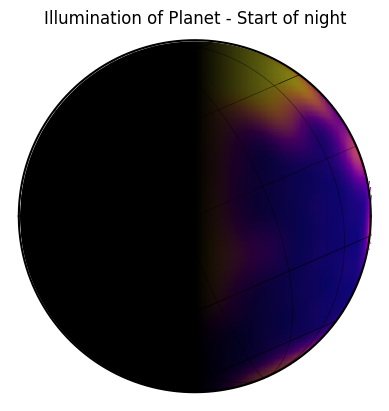

In [54]:
prox_Earth.obl = 23.5
prox_Earth.theta_init = 325.
obs_test.Planet = prox_Earth
obs_test.viz_obs(num_maps = 1, projection='ortho')

(87,) (87,) (87,)


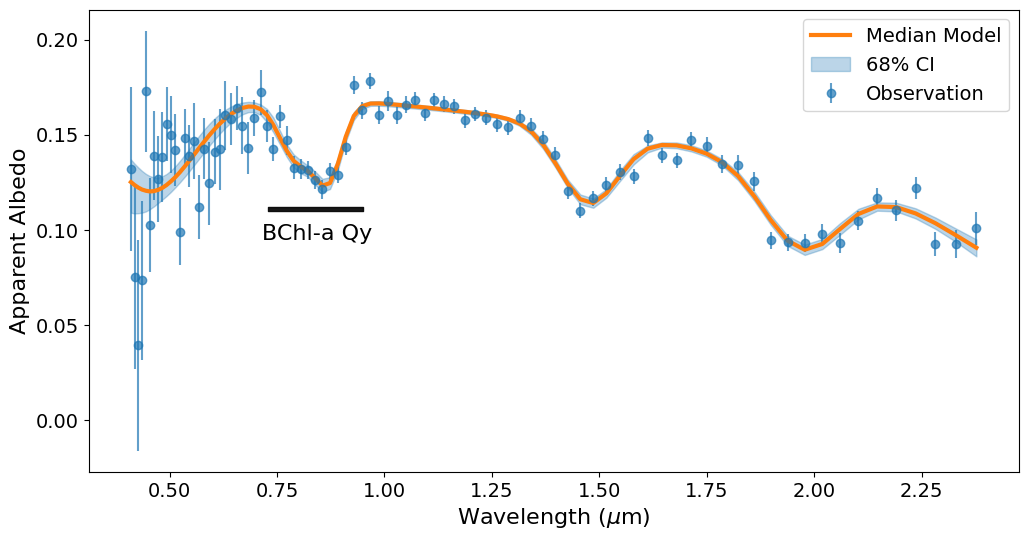

In [124]:
print(wav.shape, alb1.shape, err1.shape)

plt.figure(figsize=(12, 6))
plt.errorbar(wav_inf, alb1, yerr = err1, fmt = 'o', alpha = 0.7, label = 'Observation')
plt.plot(wav_inf, mean_vals['reflectance']['median'], label = 'Median Model', lw = 3)
plt.fill_between(wav_inf, mean_vals['reflectance']['q1'], mean_vals['reflectance']['q3'], color = 'C0', alpha = 0.3, label = '68% CI')
plt.xlabel(r'Wavelength ($\mu$m)', fontsize = 16)
plt.ylabel('Apparent Albedo', fontsize = 16)   
plt.text(0.715, 0.095, 'BChl-a Qy', fontsize = 16, color = 'k')
plt.fill_between([.73, 0.95], 0.11, 0.112, color = 'k', alpha = 0.9)
plt.legend(fontsize = 14)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.show()

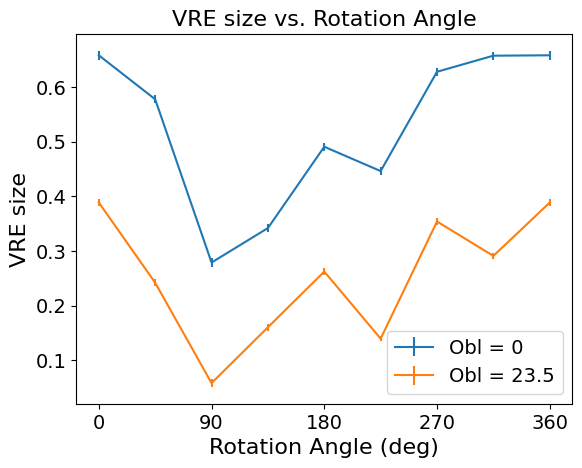

In [207]:
### For obl = 0, phase = 90 ###
rot = [0, 45, 90, 135, 180, 225, 270, 315, 360]
vre = [0.6576, 0.5772, 0.2789, 0.3419, 0.4905, 0.4460, 0.6275, 0.6569, 0.6576]
vre_err = [0.008, 0.007, 0.009, 0.007, 0.007, 0.007, 0.007, 0.007, 0.008]



### For obl = 23.5, phase = 90 ###
rot2 = [0, 45, 90, 135, 180, 225, 270, 315, 360]
vre2 = [0.3885, 0.242, 0.0586, 0.1606, 0.2624, 0.1398, 0.3539, 0.291, 0.3885]
vre_err2 = [0.006, 0.006, 0.007, 0.006, 0.006, 0.005, 0.006, 0.006, 0.006]

plt.errorbar(rot, vre, yerr = vre_err, label = 'Obl = 0')
plt.errorbar(rot2, vre2, yerr = vre_err2, label = 'Obl = 23.5')
plt.xlabel('Rotation Angle (deg)', fontsize=16)
plt.ylabel('VRE size', fontsize=16)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.legend(fontsize=14)
plt.title('VRE size vs. Rotation Angle', fontsize=16)
plt.xticks(np.arange(0, 361, 90))
plt.show()


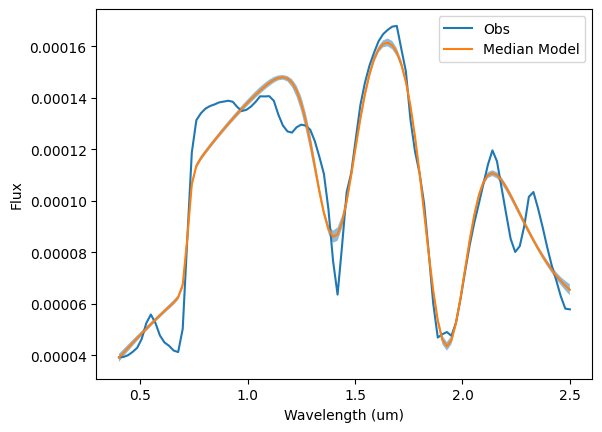

In [22]:
plt.plot(spectra['sea'][:,0], int_flux.flatten(), label = 'Obs')
plt.plot(spectra['sea'][:,0], mean_vals['reflectance']['median'], label = 'Median Model')

# for i in range(10):
#     plt.plot(spectra['sea'][:,0], trace['reflectance'][i], color = 'black', alpha = 0.1)

plt.fill_between(spectra['sea'][:,0], mean_vals['reflectance']['q1'], mean_vals['reflectance']['q3'], alpha = 0.5)

plt.xlabel('Wavelength (um)')
plt.ylabel('Flux')
plt.legend()
plt.show()

Observing at theta = 0
2.3046102379977105e-05
This observation lasts for 0.33 days at R = 33.33 (at 700 nm).
The planet moves from phase angle between 20.0 and 30.7 degrees and at a rotation angle between 0.0 and 10.7 degrees.
The planet completes 0.03 rotations and 0.03 orbits.
Fitting at theta = 0


optimizing logp for variables: [A3, sigma3, mu3, A2, sigma2, mu2, A1, sigma1, mu1, edge_size, edge_loc, smooth, c, b, a]


message: Desired error not necessarily achieved due to precision loss.


logp: -45140.973153284474 -> 1037.1384941721612
/Users/andrew/opt/anaconda3/envs/starry_stable/lib/python3.9/site-packages/deprecat/classic.py:215: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [A3, sigma3, mu3, A2, sigma2, mu2, A1, sigma1, mu1, edge_size, edge_loc, smooth, c, b, a]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 4 seconds.


...

edge_size: 0.0617 +0.0158 -0.0157
Observing at theta = 360
2.3046102379977108e-05
This observation lasts for 0.33 days at R = 33.33 (at 700 nm).
The planet moves from phase angle between 20.0 and 30.7 degrees and at a rotation angle between 360.0 and 10.7 degrees.
The planet completes 0.03 rotations and 0.03 orbits.
Fitting at theta = 360


optimizing logp for variables: [A3, sigma3, mu3, A2, sigma2, mu2, A1, sigma1, mu1, edge_size, edge_loc, smooth, c, b, a]


message: Desired error not necessarily achieved due to precision loss.
logp: -45140.97315328447 -> 1037.1384941721612
/Users/andrew/opt/anaconda3/envs/starry_stable/lib/python3.9/site-packages/deprecat/classic.py:215: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  return wrapped_(*args_, **kwargs_)
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [A3, sigma3, mu3, A2, sigma2, mu2, A1, sigma1, mu1, edge_size, edge_loc, smooth, c, b, a]


Sampling 4 chains for 500 tune and 500 draw iterations (2_000 + 2_000 draws total) took 4 seconds.


edge_size: 0.1504 +0.0158 -0.0159


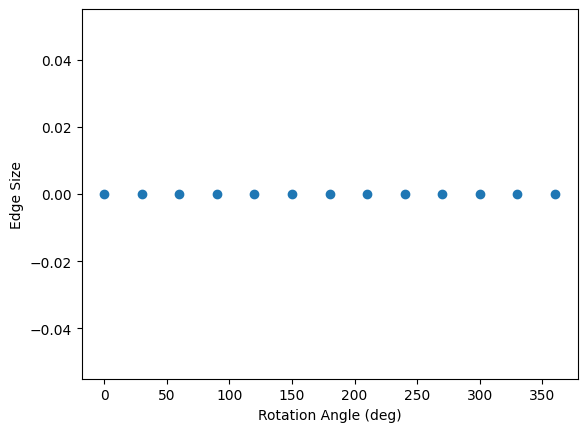

In [29]:
planet_theta = np.arange(0, 370, 30)
edge_size_inf = np.zeros_like(planet_theta)
edge_size_uerr = np.zeros_like(planet_theta)
edge_size_lerr = np.zeros_like(planet_theta)

for i in range(len(planet_theta)):
    print("Observing at theta = {}".format(planet_theta[i]))
    int_flux, int_flux_noise, flux, obs_phase, theta, obs_time, t_obs = refl_spec_obs(
        fullspecmap,
        scalarmap, 
        num_obs = 1, 
        num_nights = 1, 
        cadence = 8 * 60., 
        texp = 8 * 60., 
        phase_init = 20., 
        theta_init = planet_theta[i], 
        snr = 10.,
        Rp = R_prox_cent_b,
        a = a_prox_cent_b,
        porb = P_prox_cent_b,
        prot = P_prox_cent_b,
        dist = dist_prox_cent_b,
        plot = False
        )

    obs_data.set_value(int_flux.flatten())
    obs_sigma.set_value(np.std(int_flux.flatten())/10)

    print("Fitting at theta = {}".format(planet_theta[i]))
    with model:
        soln = pmx.optimize()

        trace = pmx.sample(
            tune=500,
            draws=500,
            start=soln,
            chains=4,
            target_accept=0.9
        )

    samples = pm.trace_to_dataframe(trace, varnames=var_names)
    corner_fig = corner(np.array(samples), labels=var_names)
    plt.savefig('/Users/andrew/Desktop/QMUL/PhD/photosynth/edge_fit_results/corner_plot_{0}.png'.format(planet_theta[i]))
    plt.close()
    
    mean_vals = dict.fromkeys(trace.varnames)

    for var in trace.varnames:
        mean_vals[var] = dict.fromkeys(['mean', 'median', 'q1', 'q3'])
        if var == 'reflectance':
            mean_vals[var]['mean'] = np.mean(trace[var], axis=0)
            mean_vals[var]['median'] = np.median(trace[var], axis = 0)
            mean_vals[var]['q1'] = np.quantile(trace[var], 0.16, axis = 0)
            mean_vals[var]['q3'] = np.quantile(trace[var], 0.84, axis = 0)
        elif var == 'edge_size':
            mean_vals[var]['mean'] = np.mean(trace[var])
            mean_vals[var]['median'] = np.median(trace[var])
            mean_vals[var]['q1'] = np.quantile(trace[var], 0.16)
            mean_vals[var]['q3'] = np.quantile(trace[var], 0.84)
            edge_size_inf[i] = np.
            edge_size_uerr[i] = mean_vals[var]['q3'] - mean_vals[var]['median']
            edge_size_lerr[i] = mean_vals[var]['median'] - mean_vals[var]['q1']
            print("{0}: {1:.4f} +{2:.4f} -{3:.4f}".format(var, mean_vals[var]['median'], mean_vals[var]['q3'] - mean_vals[var]['median'], mean_vals[var]['median'] - mean_vals[var]['q1']))
    
    fig = plt.figure()
    plt.plot(spectra['sea'][:,0], int_flux.flatten(), label = 'Obs')
    plt.plot(spectra['sea'][:,0], mean_vals['reflectance']['median'], label = 'Median Model')

    plt.fill_between(spectra['sea'][:,0], mean_vals['reflectance']['q1'], mean_vals['reflectance']['q3'], alpha = 0.5)

    plt.xlabel('Wavelength (um)')
    plt.ylabel('Flux')
    plt.legend()
    fig.savefig('/Users/andrew/Desktop/QMUL/PhD/photosynth/edge_fit_results/theta_{0}_fit.png'.format(planet_theta[i]))
    plt.close()



plt.errorbar(planet_theta, edge_size_inf, yerr = [edge_size_lerr, edge_size_uerr], fmt = 'o')
plt.xlabel('Rotation Angle (deg)')
plt.ylabel('Edge Size')
plt.show()


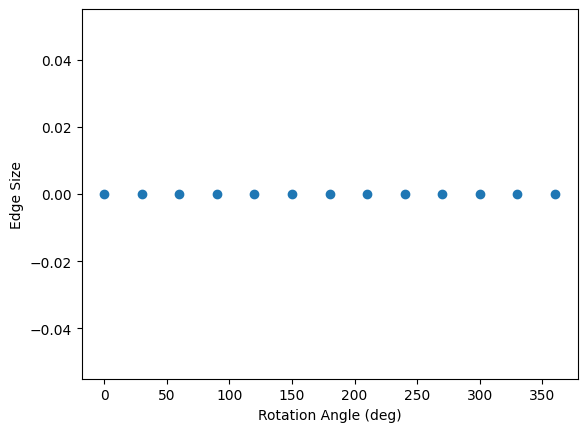

In [25]:
plt.errorbar(planet_theta, edge_size_inf, yerr = [edge_size_lerr, edge_size_uerr], fmt = 'o')
plt.xlabel('Rotation Angle (deg)')
plt.ylabel('Edge Size')
plt.show()